# Test des Modèles sur Nouvelles Données

Ce notebook permet de tester les modèles entraînés sur de nouvelles données.
- Charger les meilleurs modèles
- Tester sur vos propres images
- Obtenir les prédictions et visualiser les résultats

In [7]:
import sys
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import json

# Ajouter le chemin src au path
sys.path.insert(0, '../src')

# Importer tous les modèles et les utilitaires
from pytorch_models import (
    AdvancedCNN, ResNet50Transfer, MediumCNN, SmallVGG, FER_CNN, SEResNet
)
from pytorch_evaluate import EMOTION_LABELS

# Configuration
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device utilisé: {DEVICE}')

# Chemins
MODELS_PATH = Path('saved_models')
DATA_PATH = Path('../data')
CLASS_MAPPING_PATH = DATA_PATH / 'preprocessed' / 'class_mapping.json'

# Charger le mapping des classes
with open(CLASS_MAPPING_PATH, 'r') as f:
    class_mapping = json.load(f)

print(f'Classes: {class_mapping}')
print(f'Nombre de classes: {len(class_mapping)}')

Device utilisé: cuda
Classes: {'0': 'angry', '1': 'disgust', '2': 'fear', '3': 'happy', '4': 'neutral', '5': 'sad', '6': 'surprise'}
Nombre de classes: 7


## 1. Charger les 3 Modèles

Charge automatiquement MediumCNN, Baseline VGG et ResNet50

In [ ]:
def load_model(model_path, model_name, num_classes=7):
    """
    Charge un modèle sauvegardé en détectant automatiquement le type d'architecture
    
    Args:
        model_path: Chemin vers le fichier .pt ou .pth
        model_name: Nom du fichier (pour déterminer l'architecture)
        num_classes: Nombre de classes
    """
    # Déterminer l'architecture basée sur le nom du fichier
    name_lower = model_name.lower()
    
    try:
        if 'vgg' in name_lower or 'baseline_vgg' in name_lower:
            model = SmallVGG(num_classes=num_classes)
        elif 'mediumcnn' in name_lower:
            model = MediumCNN(num_classes=num_classes)
        elif 'resnet50' in name_lower or 'transfer' in name_lower:
            model = ResNet50Transfer(num_classes=num_classes)
        elif 'fer_cnn' in name_lower:
            model = FER_CNN(num_classes=num_classes)
        elif 'seresnet' in name_lower:
            model = SEResNet(num_classes=num_classes)
        else:
            # Par défaut, essayer AdvancedCNN
            model = AdvancedCNN(num_classes=num_classes)
        
        # Charger les poids
        checkpoint = torch.load(model_path, map_location=DEVICE)
        if isinstance(checkpoint, dict):
            if 'model_state_dict' in checkpoint:
                model.load_state_dict(checkpoint['model_state_dict'])
            elif 'state_dict' in checkpoint:
                model.load_state_dict(checkpoint['state_dict'])
            else:
                model.load_state_dict(checkpoint)
        else:
            model.load_state_dict(checkpoint)
        
        model = model.to(DEVICE)
        model.eval()
        return model
    except Exception as e:
        print(f'  ⚠️ Erreur lors du chargement: {e}')
        return None

# ===== CHARGER LES 3 MEILLEURS MODÈLES =====

print(f'Chemin des modèles: {MODELS_PATH}\n')
print('Fichiers disponibles:')
if MODELS_PATH.exists():
    available_files = list(MODELS_PATH.glob('*.pth')) + list(MODELS_PATH.glob('*.pt'))
    if available_files:
        for f in sorted(available_files)[:10]:  # Show first 10
            print(f'  - {f.name}')
        if len(available_files) > 10:
            print(f'  ... et {len(available_files) - 10} autres fichiers')
    else:
        print('  ✗ Aucun fichier .pth ou .pt trouvé!')
else:
    print(f'  ✗ Dossier non trouvé: {MODELS_PATH}')

models_to_load = [
    ('MediumCNN_best.pth', 'MediumCNN (0.70)'),
    ('baseline_vgg_best_model.pth', 'Baseline VGG (0.698)'),
    ('ResNet50_best.pth', 'ResNet50 (0.68)'),
    ('fer_cnn_0.66.pth', 'FER-CNN (0.66)'),
    ('exp11_seresnet_lr1e-04_bs16_best.pt', 'SEResNet (0.65)'),
]

loaded_models = {}
print('\n' + '=' * 60)
print('Chargement des modèles...')
print('=' * 60)

for model_file, display_name in models_to_load:
    model_path = MODELS_PATH / model_file
    print(f'\n{display_name}:')
    print(f'  Chemin: {model_path}')
    print(f'  Existe: {model_path.exists()}')
    
    if model_path.exists():
        model = load_model(model_path, model_file)
        if model is not None:
            loaded_models[display_name] = model
            print(f'  ✓ Chargé avec succès!')
        else:
            print(f'  ✗ Erreur lors du chargement')
    else:
        print(f'  ✗ Fichier non trouvé')

print('\n' + '=' * 60)
print(f'✓ {len(loaded_models)}/{len(models_to_load)} modèles chargés\n')

if len(loaded_models) == 0:
    print('⚠️ ATTENTION: Aucun modèle n\'a été chargé!')
    print('Vérifiez que les fichiers .pth existent dans:')
    print(f'  {MODELS_PATH}')
    print('\nNoms attendus:')
    for model_file, _ in models_to_load:
        print(f'  - {model_file}')

Chemin des modèles: saved_models

Fichiers disponibles:
  - baseline_vgg_best_model.pth
  - exp10_mobilenetv2_lr5e-04_bs48_best.pt
  - exp10_mobilenetv2_lr5e-04_bs48_final.pt
  - exp11_seresnet_lr1e-04_bs16_best.pt
  - exp11_seresnet_lr1e-04_bs16_final.pt
  - exp12_advanced_lr1e-03_bs32_best.pt
  - exp12_advanced_lr1e-03_bs32_final.pt
  - exp13_densenet_lr1e-03_bs48_best.pt
  - exp13_densenet_lr1e-03_bs48_final.pt
  - exp1_resnet_lr1e-03_bs32_best.pt
  ... et 26 autres fichiers

Chargement des modèles...

MediumCNN (0.70):
  Chemin: saved_models\MediumCNN_best.pth
  Existe: True


C:\Users\Yasmine Sassi\AppData\Local\Temp\ipykernel_19692\4027816638.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=DE

  ✓ Chargé avec succès!

Baseline VGG (0.698):
  Chemin: saved_models\baseline_vgg_best_model.pth
  Existe: True
  ✓ Chargé avec succès!

ResNet50:
  Chemin: saved_models\ResNet50_best.pth
  Existe: True
  ✓ Chargé avec succès!

FER-CNN (0.66):
  Chemin: saved_models\fer_cnn_0.66.pth
  Existe: True
  ✓ Chargé avec succès!

SEResNet (0.65):
  Chemin: saved_models\exp11_seresnet_lr1e-04_bs16_best.pt
  Existe: True
  ✓ Chargé avec succès!

✓ 5/5 modèles chargés



## 2. Sélectionner une Image

Choisissez une image de votre PC à tester

In [9]:
import tkinter as tk
from tkinter import filedialog

def preprocess_image(image_path, size=48):
    """
    Charge et prétraite une image
    
    Args:
        image_path: Chemin vers l'image
        size: Taille de sortie (48x48 par défaut)
    
    Returns:
        Image normalisée (numpy array)
    """
    # Charger l'image
    img = Image.open(image_path)
    
    # Convertir en grayscale si nécessaire
    if img.mode != 'L':
        img = img.convert('L')
    
    # Redimensionner
    img = img.resize((size, size), Image.Resampling.LANCZOS)
    
    # Convertir en array numpy
    img_array = np.array(img, dtype=np.float32)
    
    # Normaliser (0-1)
    img_array = img_array / 255.0
    
    return img_array

# ===== SÉLECTIONNER UNE IMAGE DEPUIS VOTRE PC =====
# Cliquez sur le bouton pour ouvrir le sélecteur de fichier

print('Cliquez sur "Parcourir" pour sélectionner une image...\n')

# Créer une fenêtre Tkinter cachée
root = tk.Tk()
root.withdraw()

# Ouvrir le dialogue de sélection de fichier
IMAGE_PATH = filedialog.askopenfilename(
    title='Sélectionner une image à tester',
    filetypes=[
        ('Images', '*.jpg *.jpeg *.png *.bmp'),
        ('JPG files', '*.jpg *.jpeg'),
        ('PNG files', '*.png'),
        ('All files', '*.*')
    ]
)

root.destroy()

# Charger l'image
img_array = None
if IMAGE_PATH:
    try:
        img_array = preprocess_image(IMAGE_PATH)
        print(f'✓ Image chargée avec succès!')
        print(f'  Nom: {Path(IMAGE_PATH).name}')
        print(f'  Chemin: {IMAGE_PATH}')
        print(f'  Shape: {img_array.shape}')
    except Exception as e:
        print(f'✗ Erreur lors du chargement de l\'image: {e}')
else:
    print(f'✗ Aucune image sélectionnée')

Cliquez sur "Parcourir" pour sélectionner une image...

✓ Image chargée avec succès!
  Nom: man.jpeg
  Chemin: C:/Users/Yasmine Sassi/Downloads/man.jpeg
  Shape: (48, 48)


## 3. Tester les 3 Modèles

Effectue les prédictions avec tous les modèles et affiche les résultats

In [10]:
# ===== TESTER LES 3 MODÈLES SUR L'IMAGE =====

if img_array is not None and len(loaded_models) > 0:
    print('\n' + '='*70)
    print('PRÉDICTIONS DES 3 MODÈLES')
    print('='*70)
    
    # Préparer l'image pour les modèles
    img_tensor = torch.from_numpy(img_array).float()
    img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)  # (1, 1, 48, 48)
    img_tensor = img_tensor.to(DEVICE)
    
    # Charger les noms des émotions
    emotion_names = list(class_mapping.values())
    
    # Faire les prédictions avec tous les modèles
    all_predictions = {}
    
    for model_name, model in loaded_models.items():
        with torch.no_grad():
            outputs = model(img_tensor)
            probabilities = torch.softmax(outputs, dim=1)[0].cpu().numpy()
            pred_idx = np.argmax(probabilities)
            pred_emotion = emotion_names[pred_idx]
            confidence = probabilities[pred_idx]
            
            all_predictions[model_name] = {
                'emotion': pred_emotion,
                'confidence': confidence,
                'probabilities': probabilities
            }
            
            print(f'\n{model_name}:')
            print(f'  Émotion: {pred_emotion}')
            print(f'  Confiance: {confidence:.2%}')
    
    # Calculer la prédiction ensemble (vote majoritaire)
    predicted_emotions = [all_predictions[name]['emotion'] for name in all_predictions.keys()]
    emotion_counts = {}
    for emotion in predicted_emotions:
        emotion_counts[emotion] = emotion_counts.get(emotion, 0) + 1
    
    ensemble_emotion = max(emotion_counts, key=emotion_counts.get)
    ensemble_confidence = emotion_counts[ensemble_emotion] / len(all_predictions)
    
    print(f'\n' + '='*70)
    print(f'ENSEMBLE PREDICTION (Vote Majoritaire):')
    print(f'  Émotion: {ensemble_emotion}')
    print(f'  Accord: {ensemble_confidence:.0%} des modèles')
    print('='*70)
    
else:
    if img_array is None:
        print('✗ Aucune image chargée. Veuillez charger une image d\'abord.')
    else:
        print('✗ Aucun modèle chargé.')


PRÉDICTIONS DES 3 MODÈLES

MediumCNN (0.70):
  Émotion: fear
  Confiance: 46.71%

Baseline VGG (0.698):
  Émotion: sad
  Confiance: 24.33%

ResNet50:
  Émotion: surprise
  Confiance: 59.83%

FER-CNN (0.66):
  Émotion: happy
  Confiance: 29.64%

SEResNet (0.65):
  Émotion: fear
  Confiance: 40.31%

ENSEMBLE PREDICTION (Vote Majoritaire):
  Émotion: fear
  Accord: 40% des modèles


## 4. Visualiser les Prédictions

Affiche l'image avec les probabilités de chaque modèle côte à côte

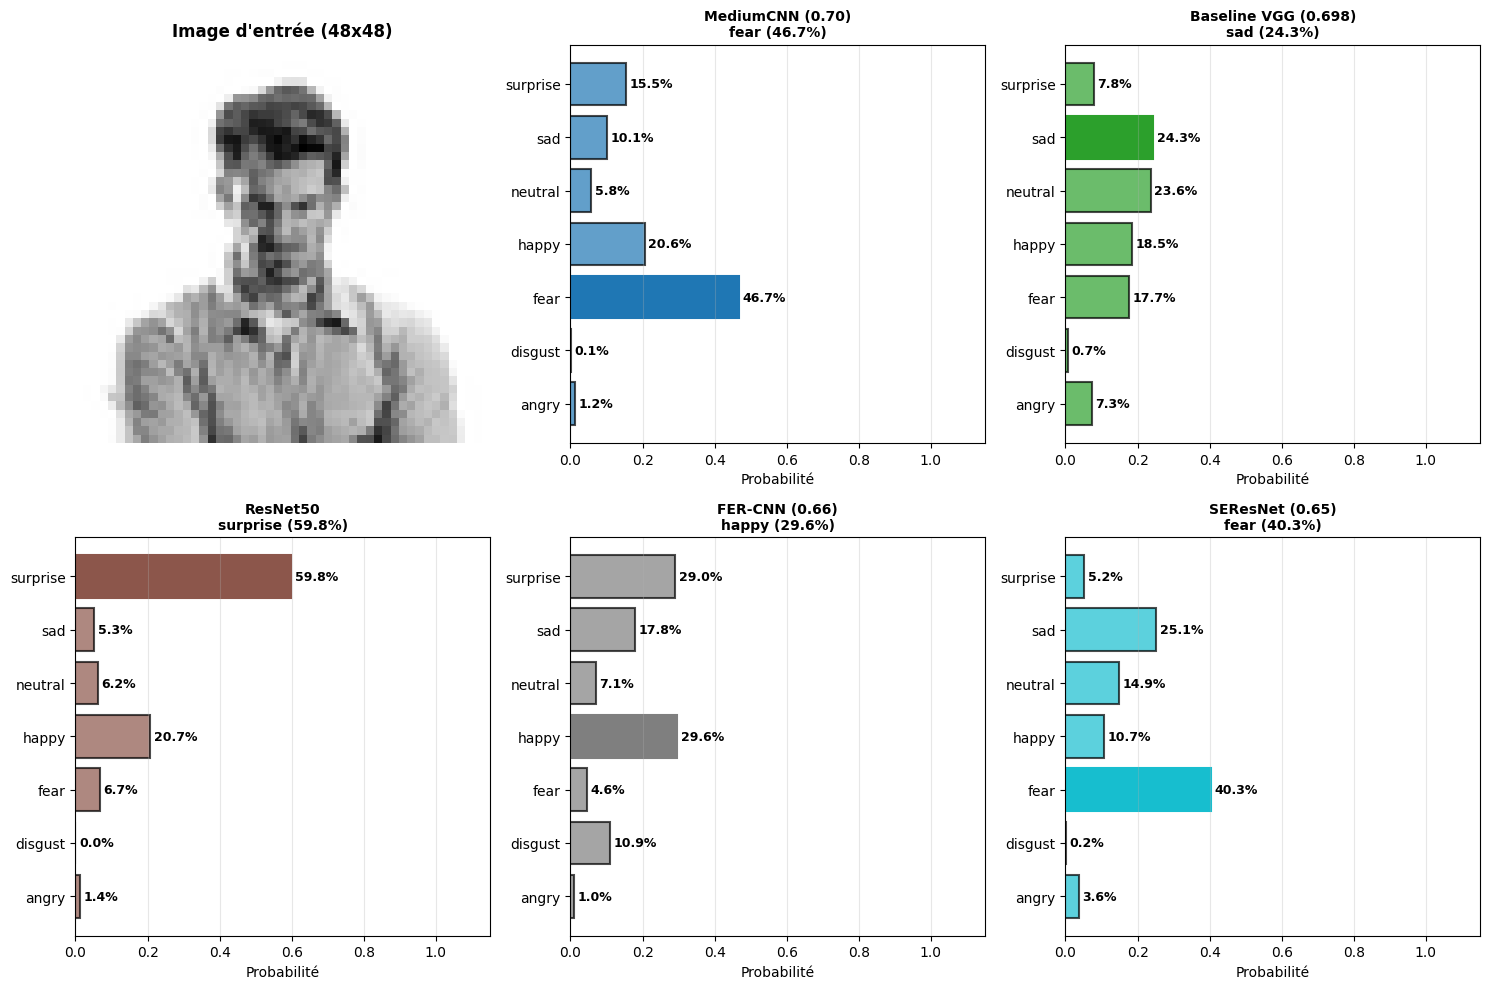


✓ Visualisation sauvegardée: evaluation\test_prediction_results.png


In [ ]:
# ===== VISUALISER LES RÉSULTATS =====

# Créer le répertoire d'évaluation s'il n'existe pas
from pathlib import Path
eval_dir = Path('evaluation')
eval_dir.mkdir(exist_ok=True)

if img_array is not None and all_predictions:
    emotion_names = list(class_mapping.values())
    
    # Créer les subplots en 2x3 (6 subplots total)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()  # Aplatir pour accès facile
    
    # Afficher l'image
    axes[0].imshow(img_array, cmap='gray', interpolation='nearest')
    axes[0].set_title('Image d\'entrée (48x48)', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Générer des couleurs dynamiquement
    import matplotlib.cm as cm
    colors = cm.tab10(np.linspace(0, 1, num_models))
    
    # Afficher les prédictions pour chaque modèle
    model_names = list(all_predictions.keys())
    
    for idx, (model_name, color) in enumerate(zip(model_names, colors)):
        ax = axes[idx + 1]
        probs = all_predictions[model_name]['probabilities']
        
        # Créer le graphique en barres
        bars = ax.barh(emotion_names, probs, color=color, alpha=0.7, edgecolor='black', linewidth=1.5)
        
        # Mettre en évidence la prédiction la plus probable
        max_idx = np.argmax(probs)
        bars[max_idx].set_color(color)
        bars[max_idx].set_alpha(1.0)
        
        # Ajouter les valeurs sur les barres
        for i, (bar, prob) in enumerate(zip(bars, probs)):
            width = bar.get_width()
            ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                   f'{prob:.1%}', ha='left', va='center', fontsize=9, fontweight='bold')
        
        # Configuration
        ax.set_xlim(0, 1.15)
        ax.set_xlabel('Probabilité', fontsize=10)
        pred_emotion = all_predictions[model_name]['emotion']
        pred_conf = all_predictions[model_name]['confidence']
        ax.set_title(f'{model_name}\n{pred_emotion} ({pred_conf:.1%})', fontsize=10, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    save_path = eval_dir / 'test_prediction_results.png'
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    
    print(f'\n✓ Visualisation sauvegardée: {save_path}')
else:

    print('Pas de données pour visualiser')
    plt.show()    
    print('Pas de données pour visualiser')

ÉVALUATION DES MODÈLES SUR LES IMAGES DE TEST

📁 Émotion réelle: ANGRY (958 images)
--------------------------------------------------------------------------------
  Image 1: PrivateTest_10131363.jpg
    ✗ MediumCNN (0.70): happy (36.2%)
    ✓ Baseline VGG (0.698): angry (57.4%)
    ✗ ResNet50: sad (52.7%)
    ✓ FER-CNN (0.66): angry (54.5%)
    ✓ SEResNet (0.65): angry (61.0%)


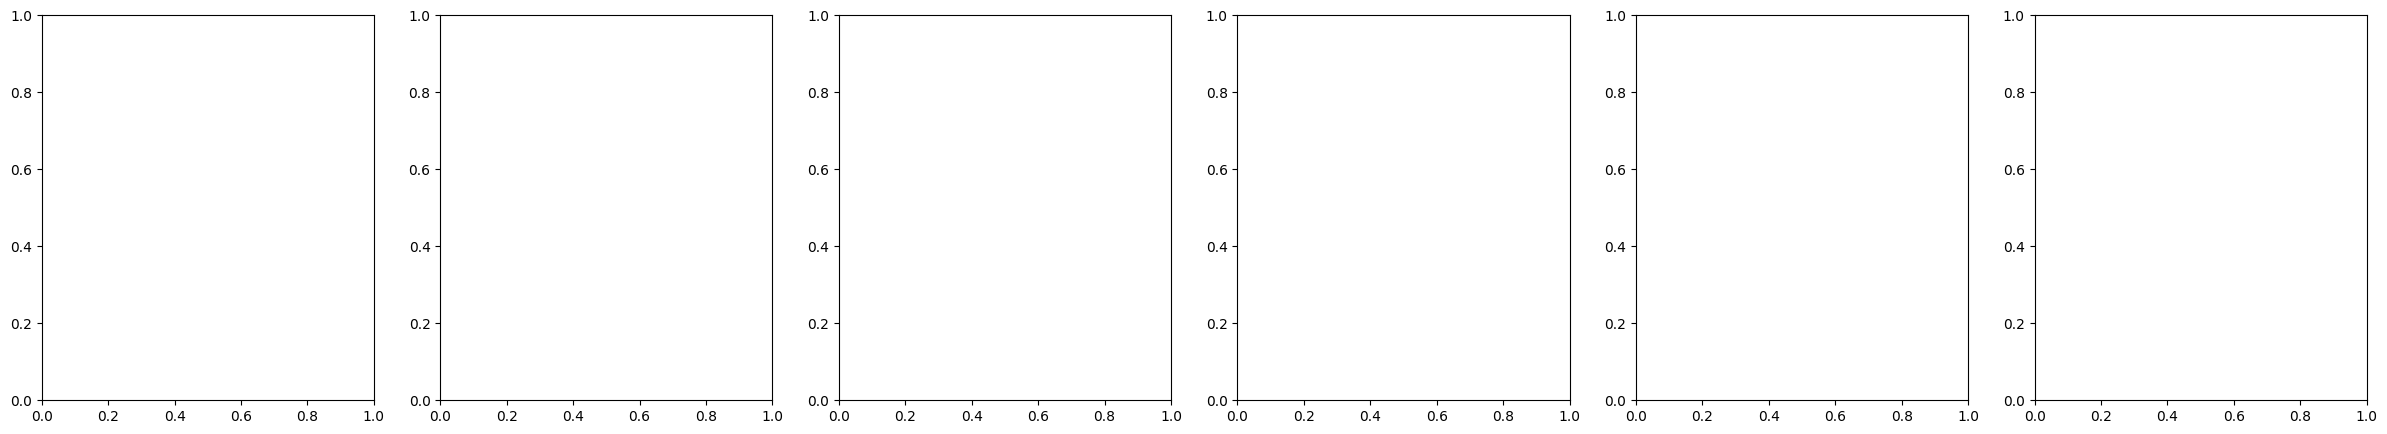

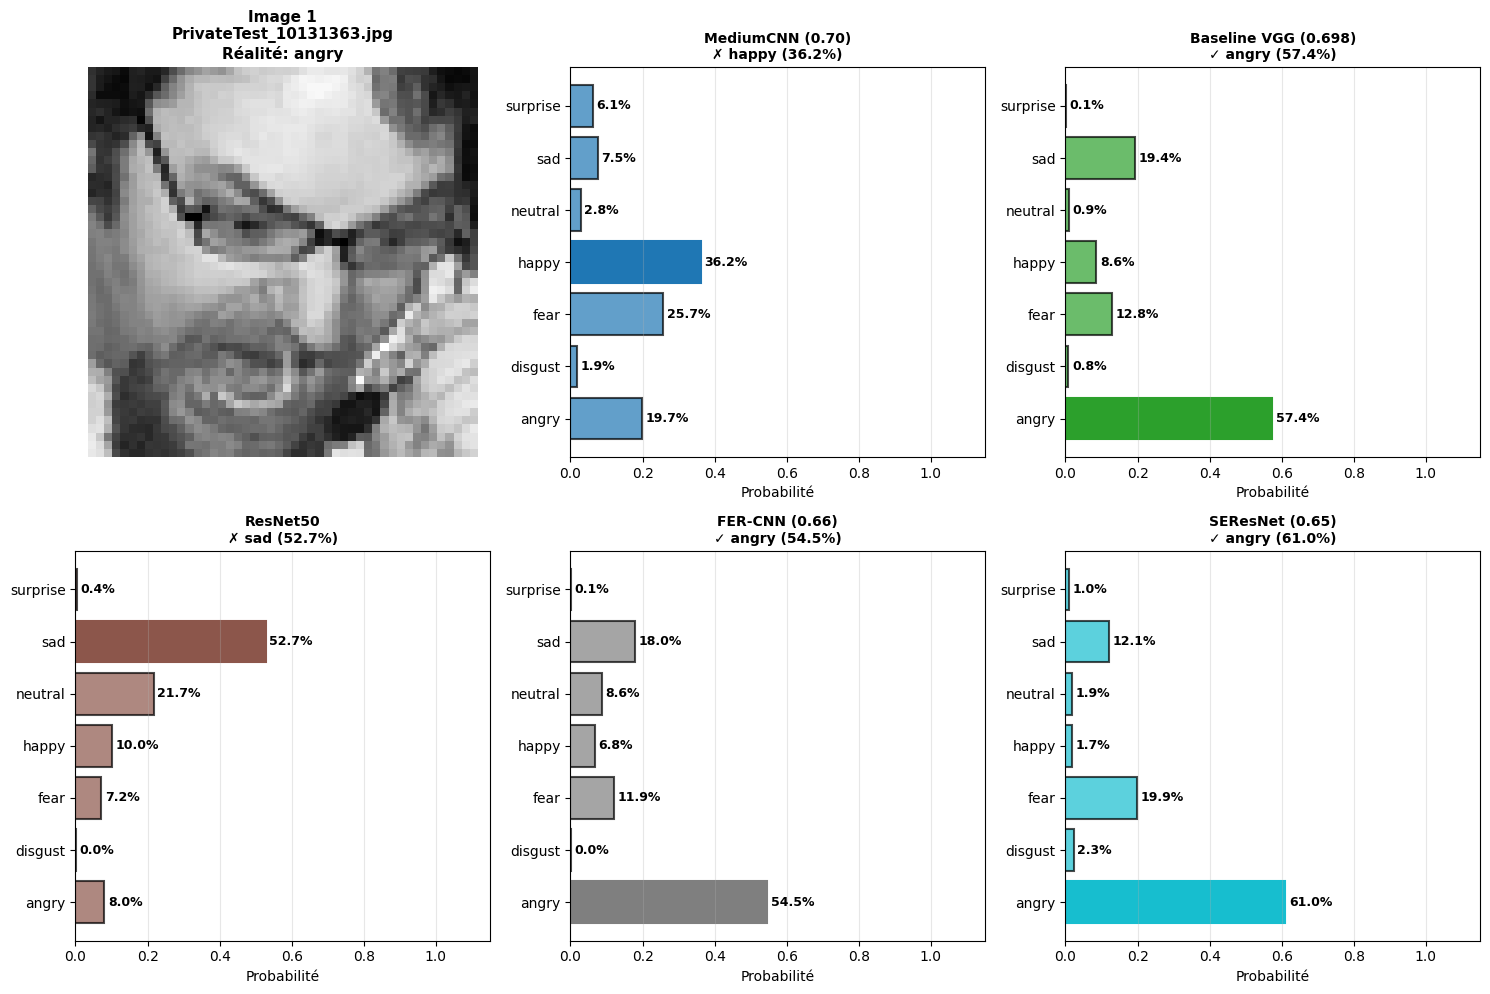

  Image 2: PrivateTest_10304478.jpg
    ✓ MediumCNN (0.70): angry (90.9%)
    ✓ Baseline VGG (0.698): angry (91.0%)
    ✓ ResNet50: angry (88.5%)
    ✗ FER-CNN (0.66): happy (57.3%)
    ✓ SEResNet (0.65): angry (85.5%)


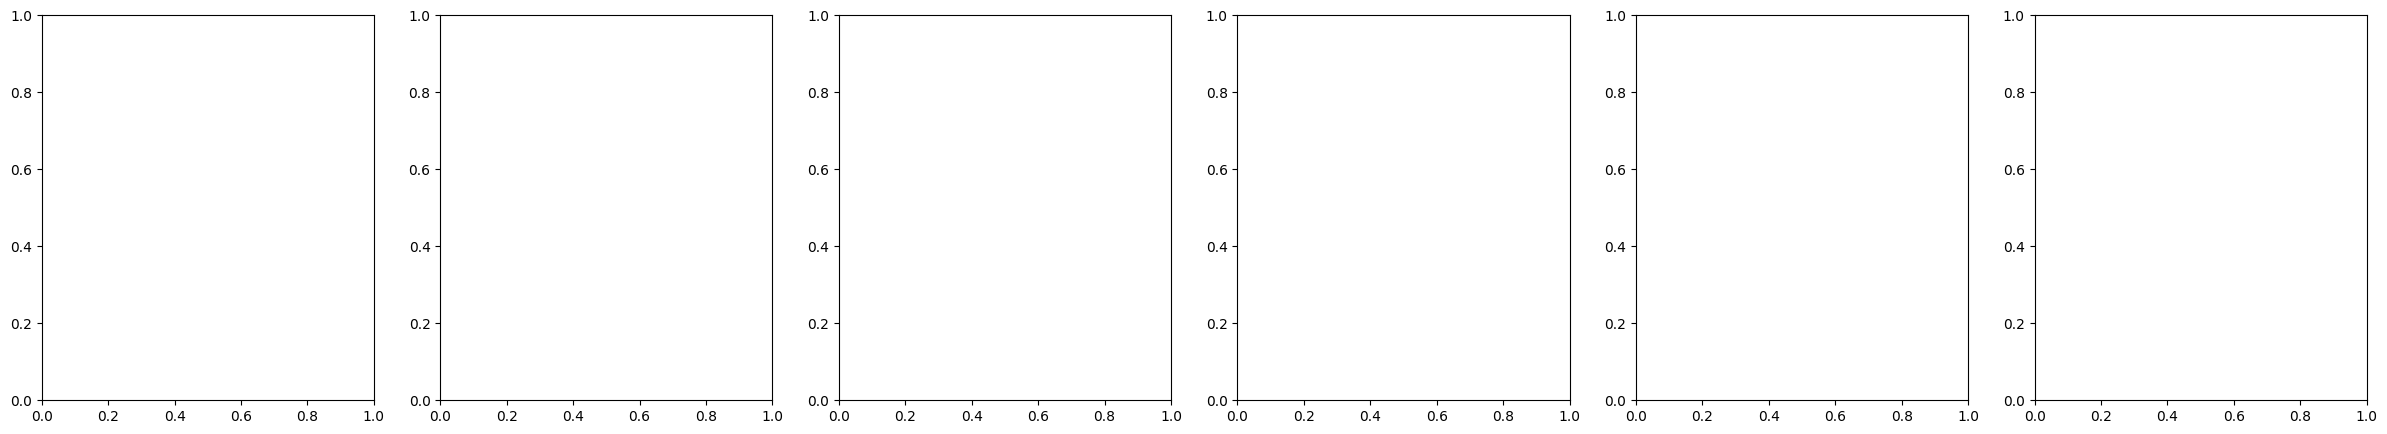

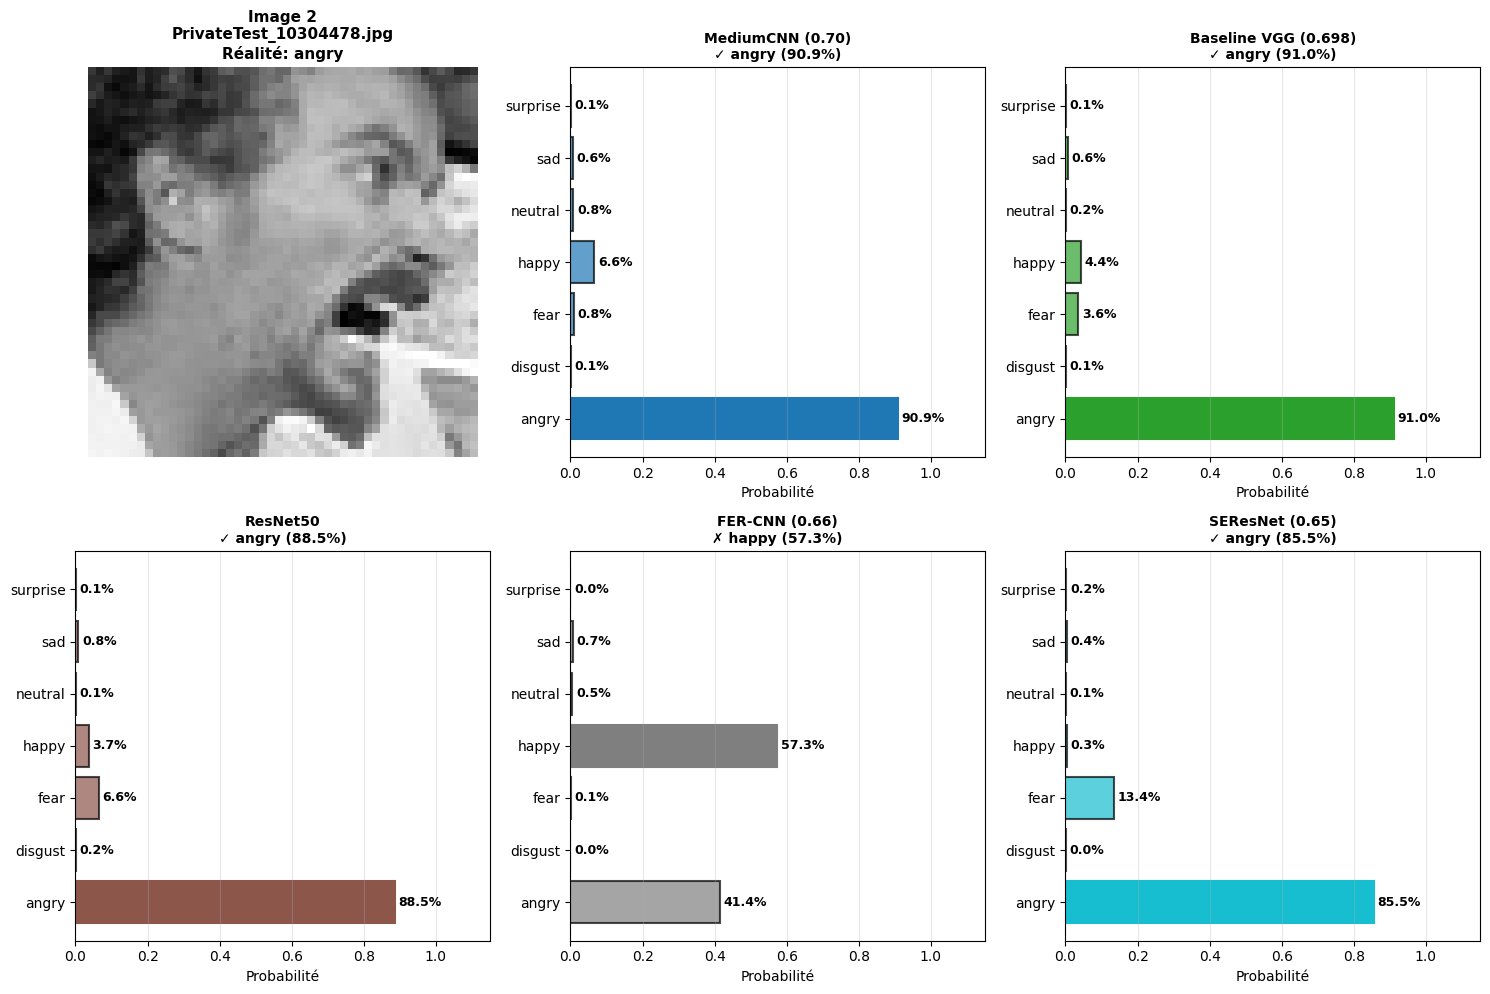

  Image 3: PrivateTest_1054527.jpg
    ✗ MediumCNN (0.70): sad (88.7%)
    ✗ Baseline VGG (0.698): sad (31.3%)
    ✗ ResNet50: sad (46.8%)
    ✗ FER-CNN (0.66): neutral (67.7%)
    ✗ SEResNet (0.65): sad (59.8%)


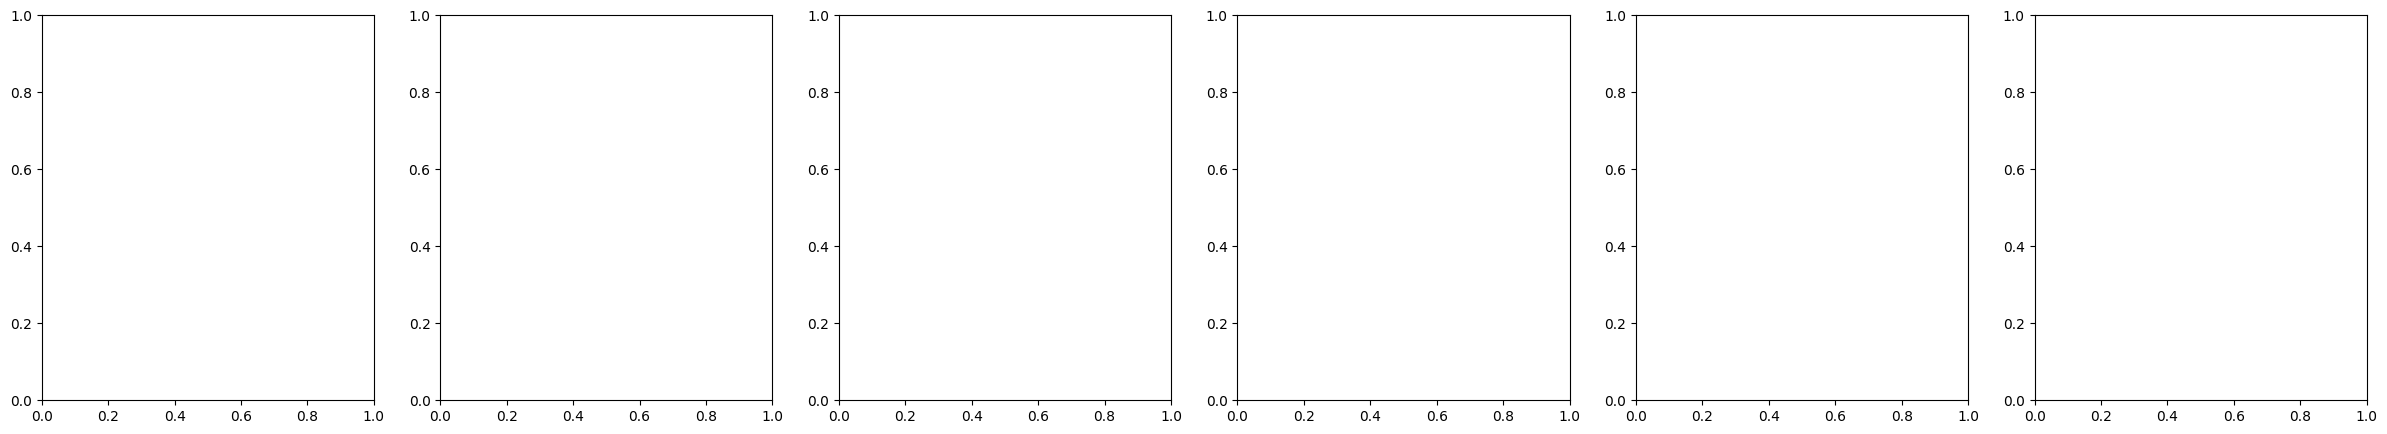

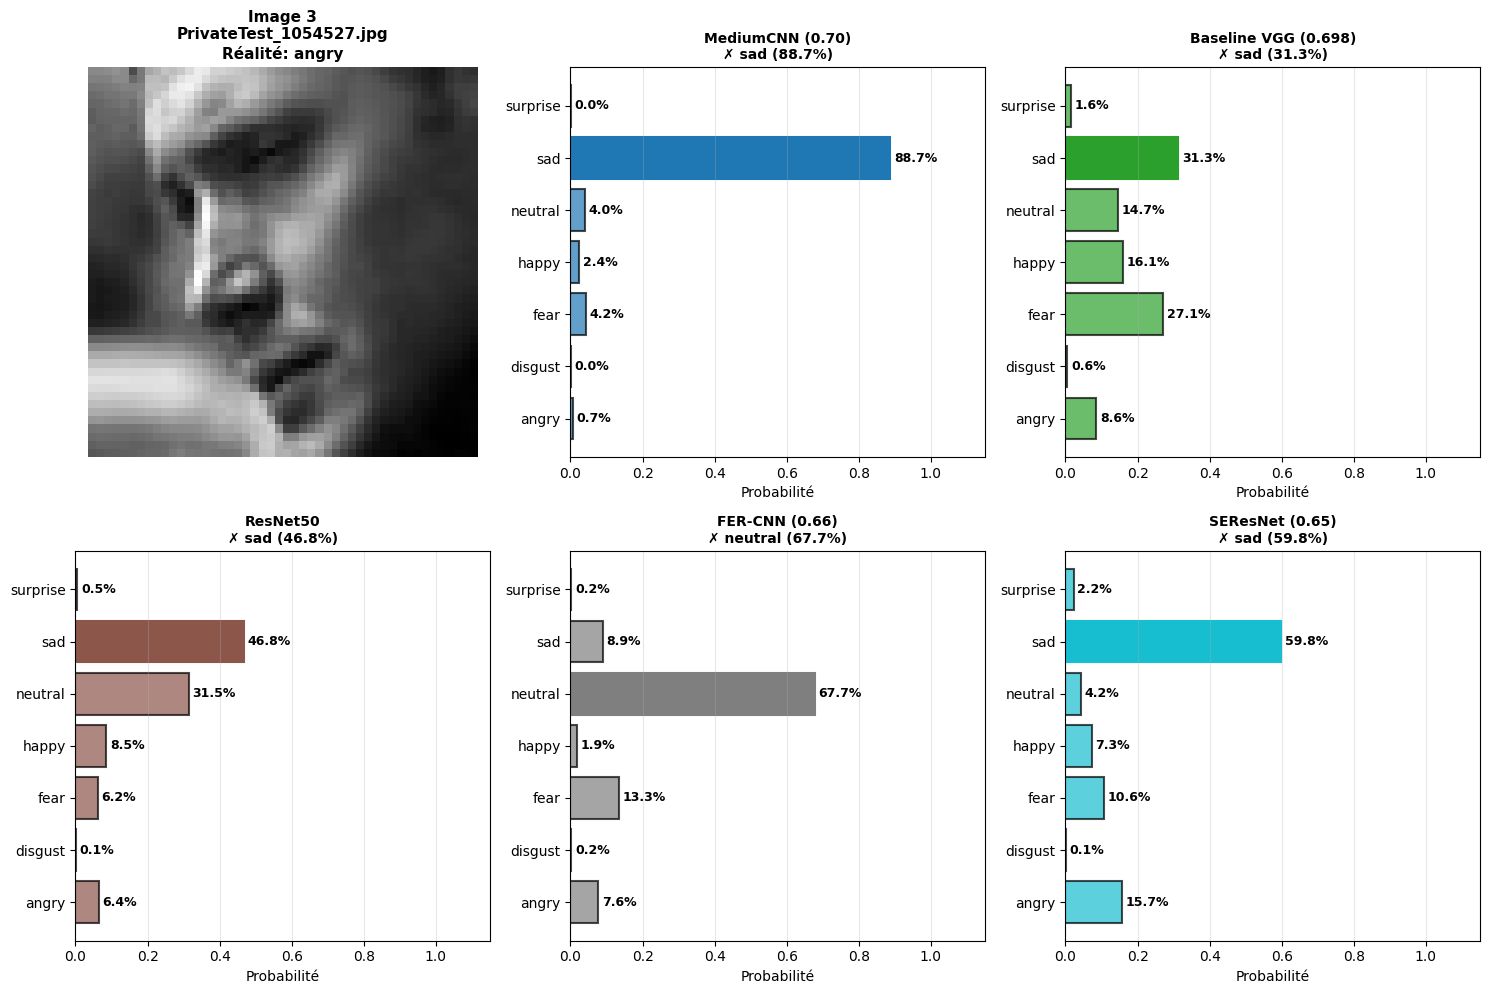


  Résumé (angry):
    MediumCNN (0.70): 1/3 correct (33%)
    Baseline VGG (0.698): 2/3 correct (67%)
    ResNet50: 1/3 correct (33%)
    FER-CNN (0.66): 1/3 correct (33%)
    SEResNet (0.65): 2/3 correct (67%)

📁 Émotion réelle: DISGUST (111 images)
--------------------------------------------------------------------------------
  Image 1: PrivateTest_11895083.jpg
    ✗ MediumCNN (0.70): fear (89.4%)
    ✗ Baseline VGG (0.698): surprise (46.6%)
    ✗ ResNet50: fear (45.9%)
    ✗ FER-CNN (0.66): fear (38.2%)
    ✗ SEResNet (0.65): surprise (40.1%)


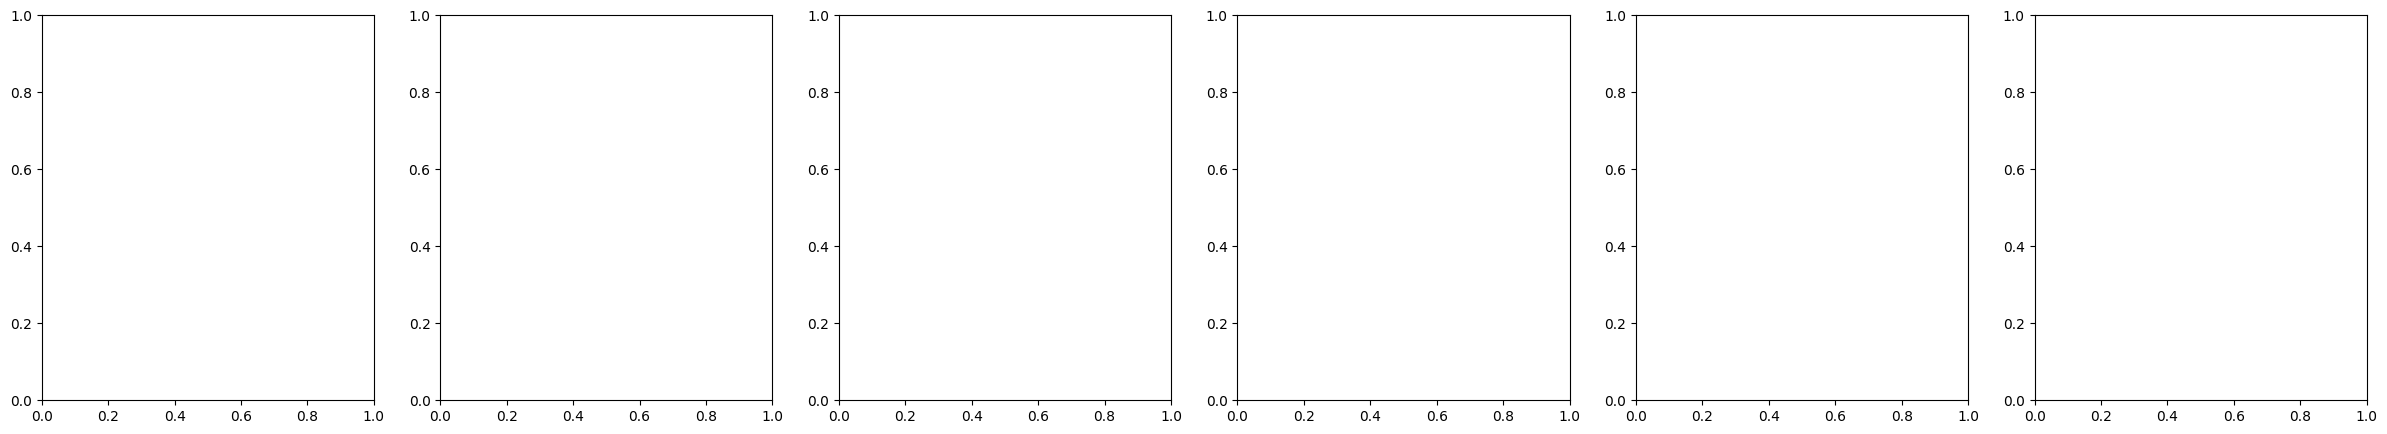

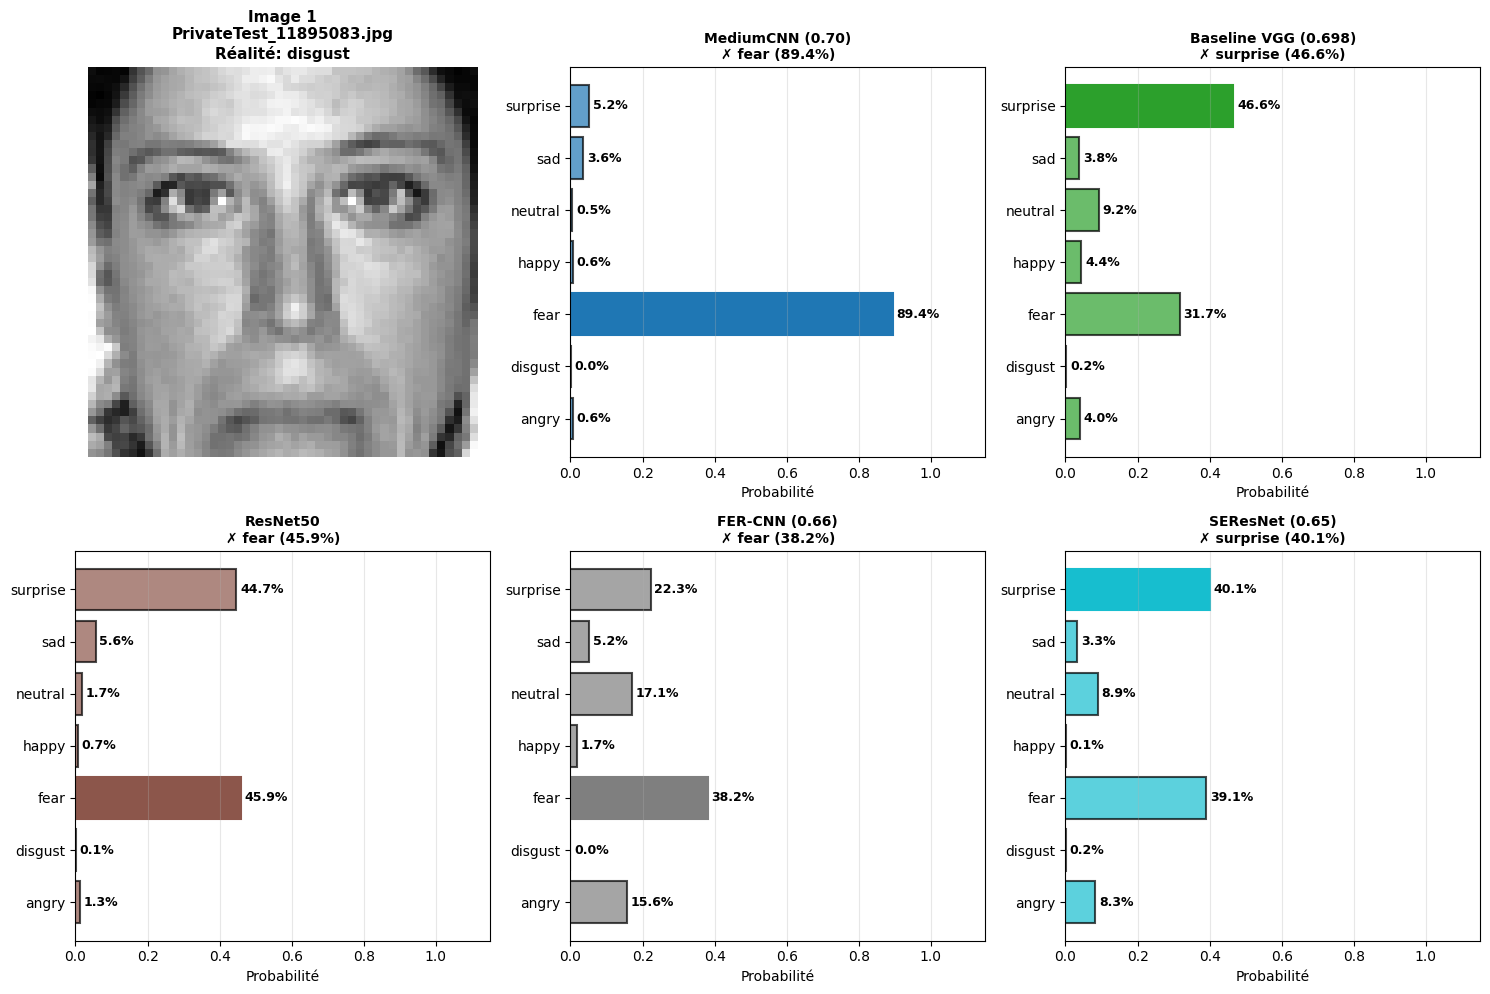

  Image 2: PrivateTest_19671520.jpg
    ✗ MediumCNN (0.70): fear (87.1%)
    ✗ Baseline VGG (0.698): happy (45.6%)
    ✗ ResNet50: neutral (38.2%)
    ✗ FER-CNN (0.66): sad (47.5%)
    ✓ SEResNet (0.65): disgust (35.5%)


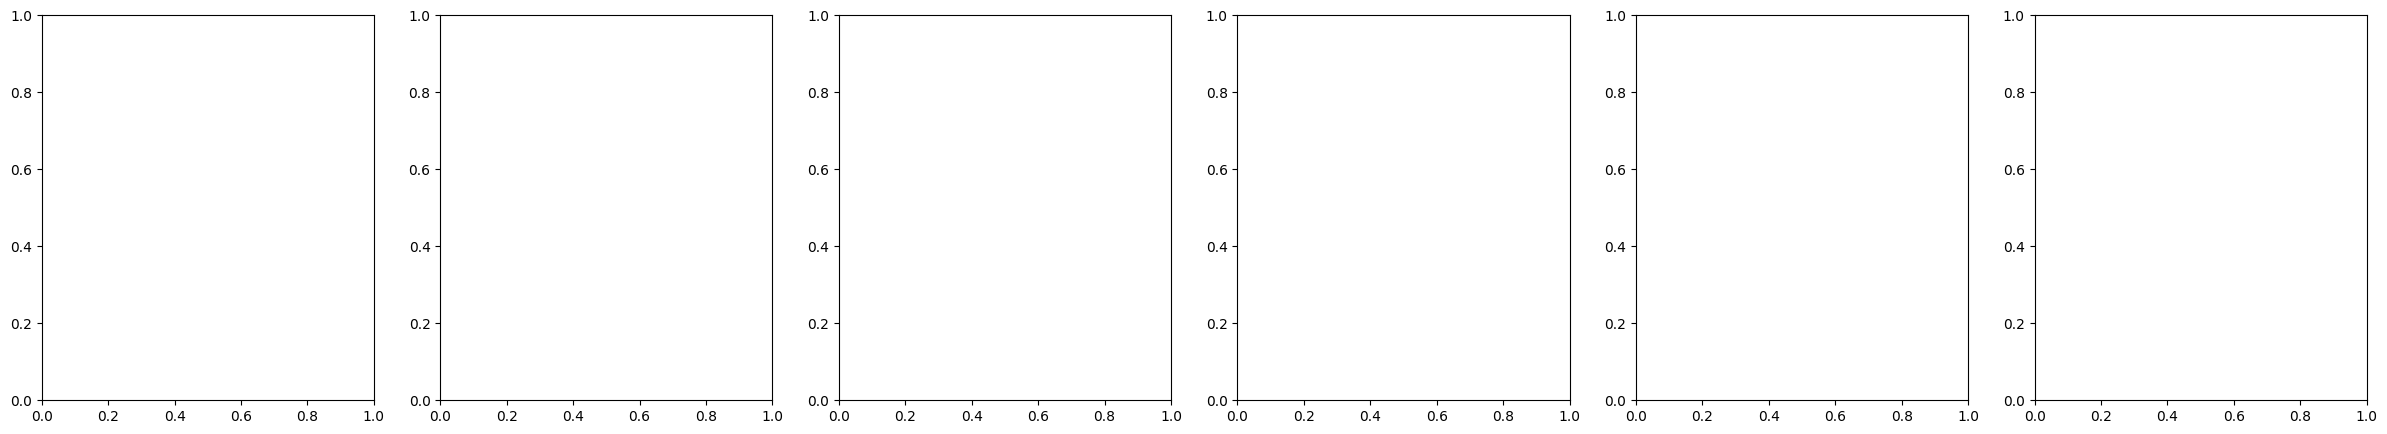

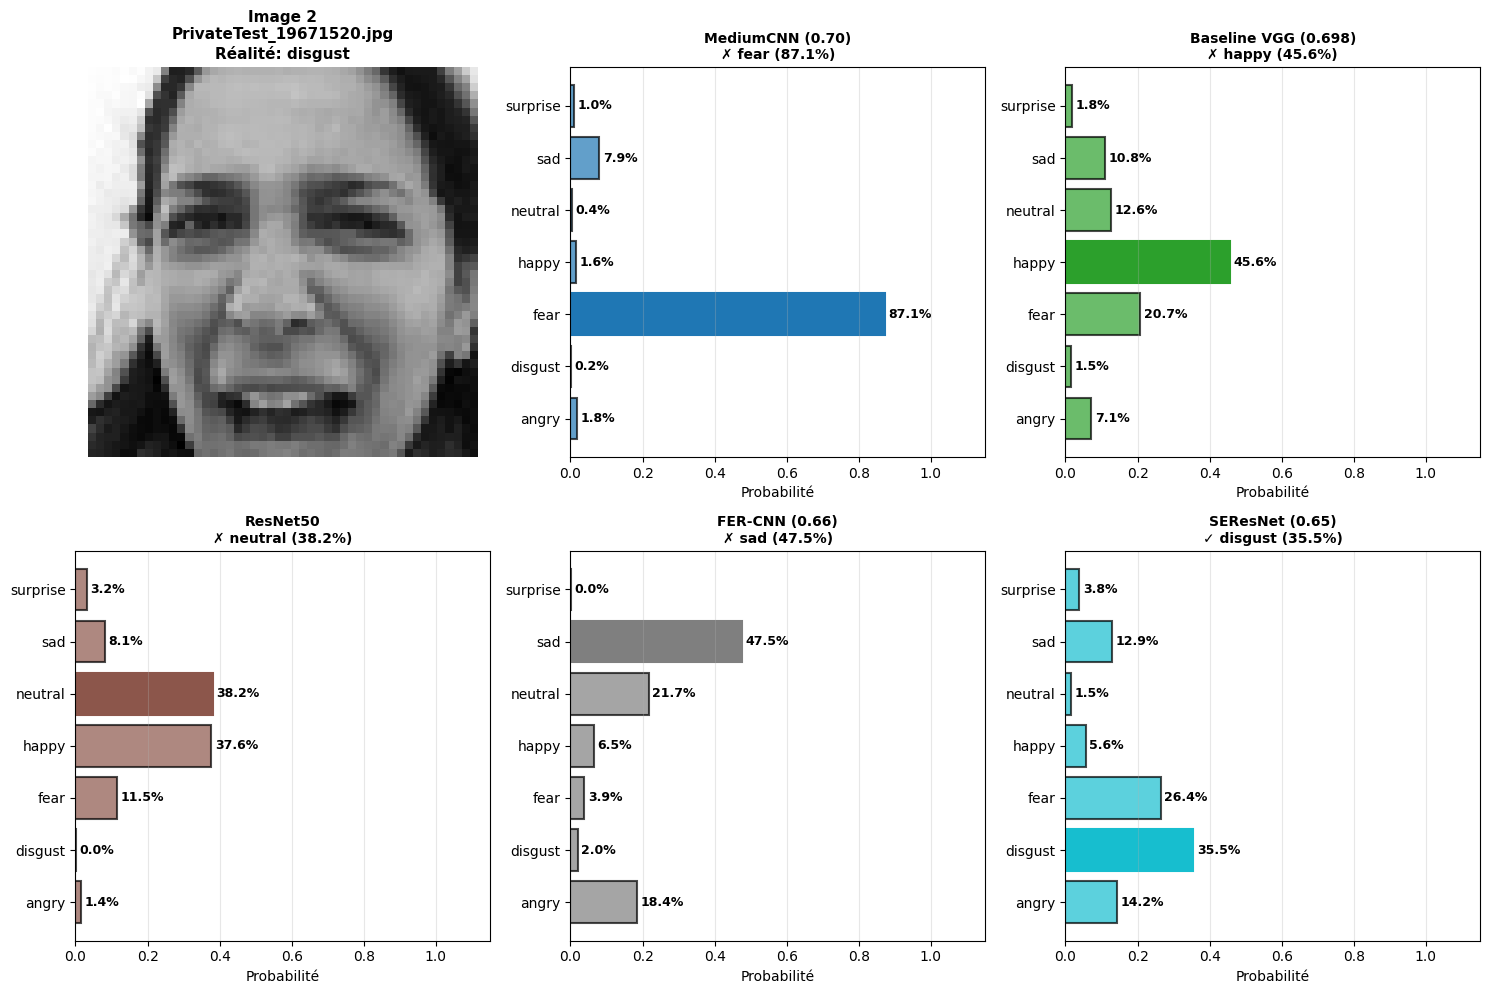

  Image 3: PrivateTest_21629266.jpg
    ✓ MediumCNN (0.70): disgust (50.1%)
    ✗ Baseline VGG (0.698): angry (49.8%)
    ✗ ResNet50: angry (79.0%)
    ✓ FER-CNN (0.66): disgust (99.8%)
    ✓ SEResNet (0.65): disgust (73.1%)


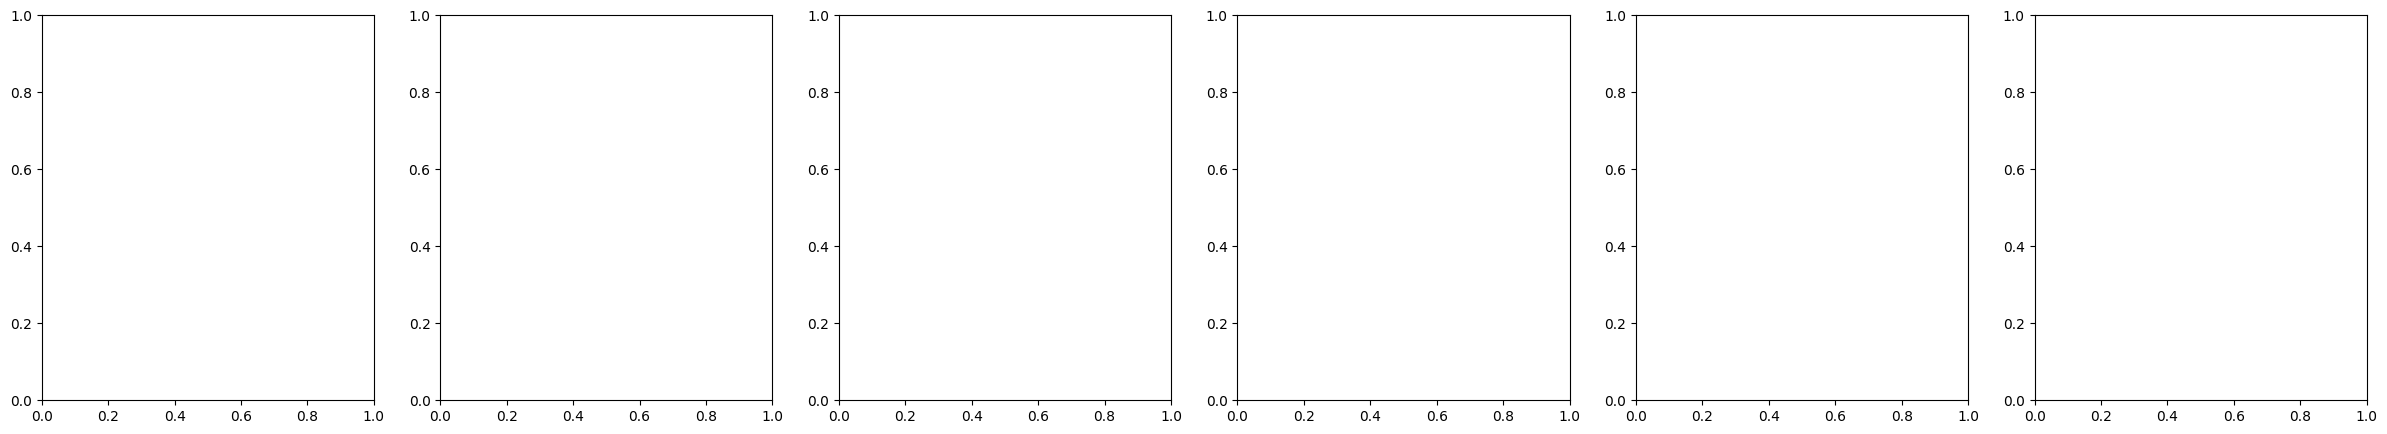

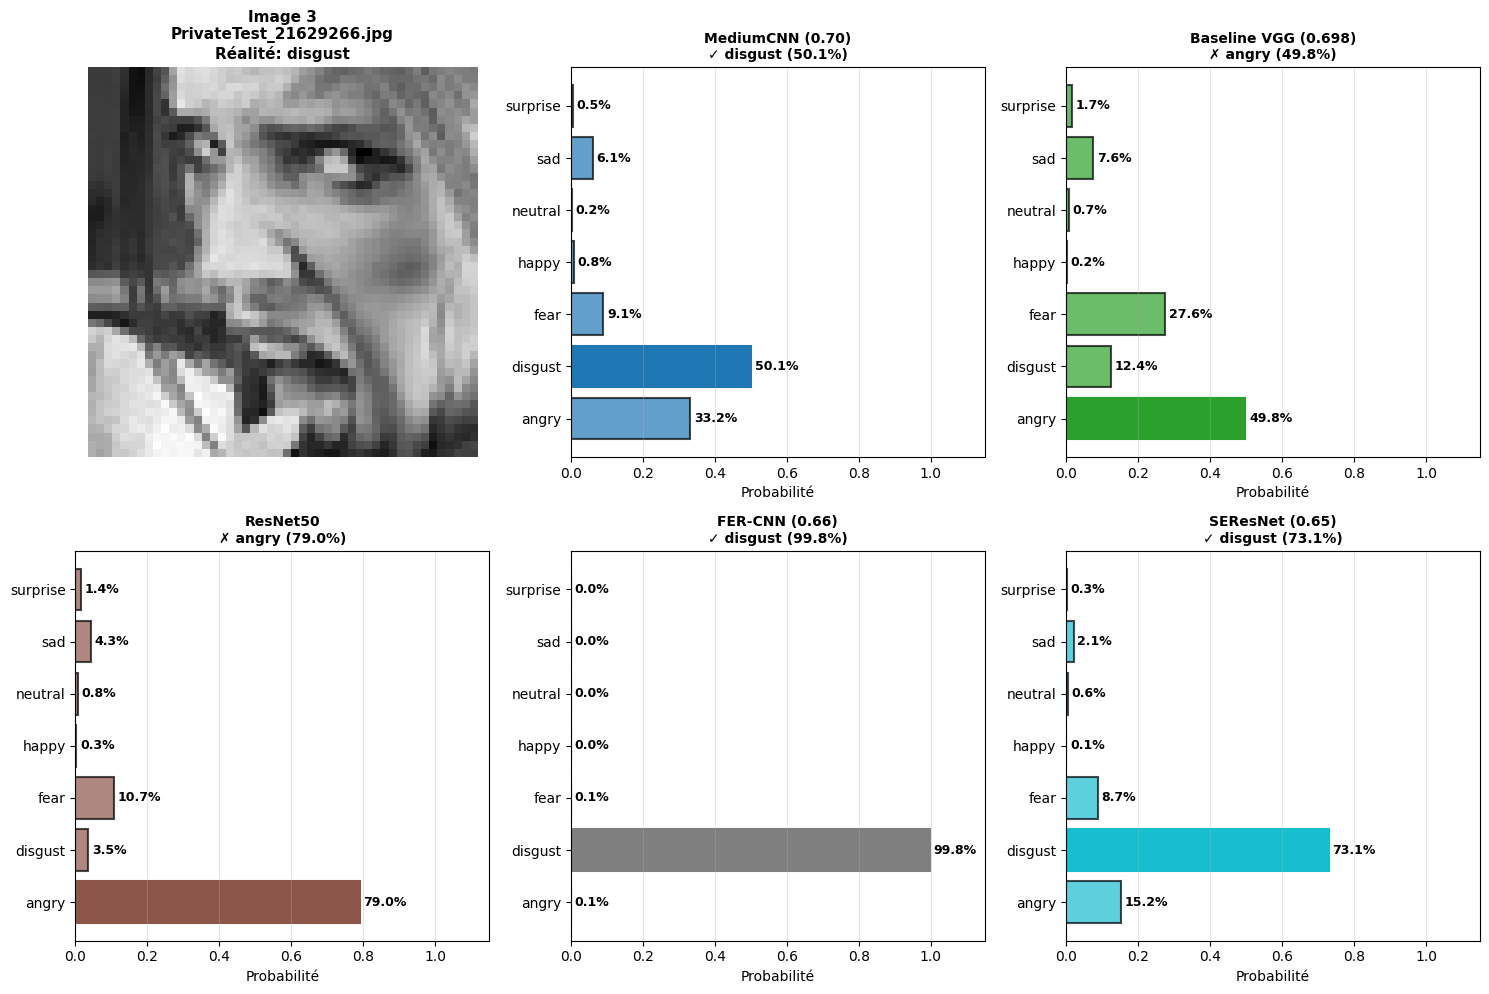


  Résumé (disgust):
    MediumCNN (0.70): 1/3 correct (33%)
    Baseline VGG (0.698): 0/3 correct (0%)
    ResNet50: 0/3 correct (0%)
    FER-CNN (0.66): 1/3 correct (33%)
    SEResNet (0.65): 2/3 correct (67%)

📁 Émotion réelle: FEAR (1024 images)
--------------------------------------------------------------------------------
  Image 1: PrivateTest_10153550.jpg
    ✗ MediumCNN (0.70): happy (69.4%)
    ✗ Baseline VGG (0.698): happy (71.3%)
    ✗ ResNet50: happy (80.3%)
    ✓ FER-CNN (0.66): fear (67.3%)
    ✓ SEResNet (0.65): fear (30.9%)


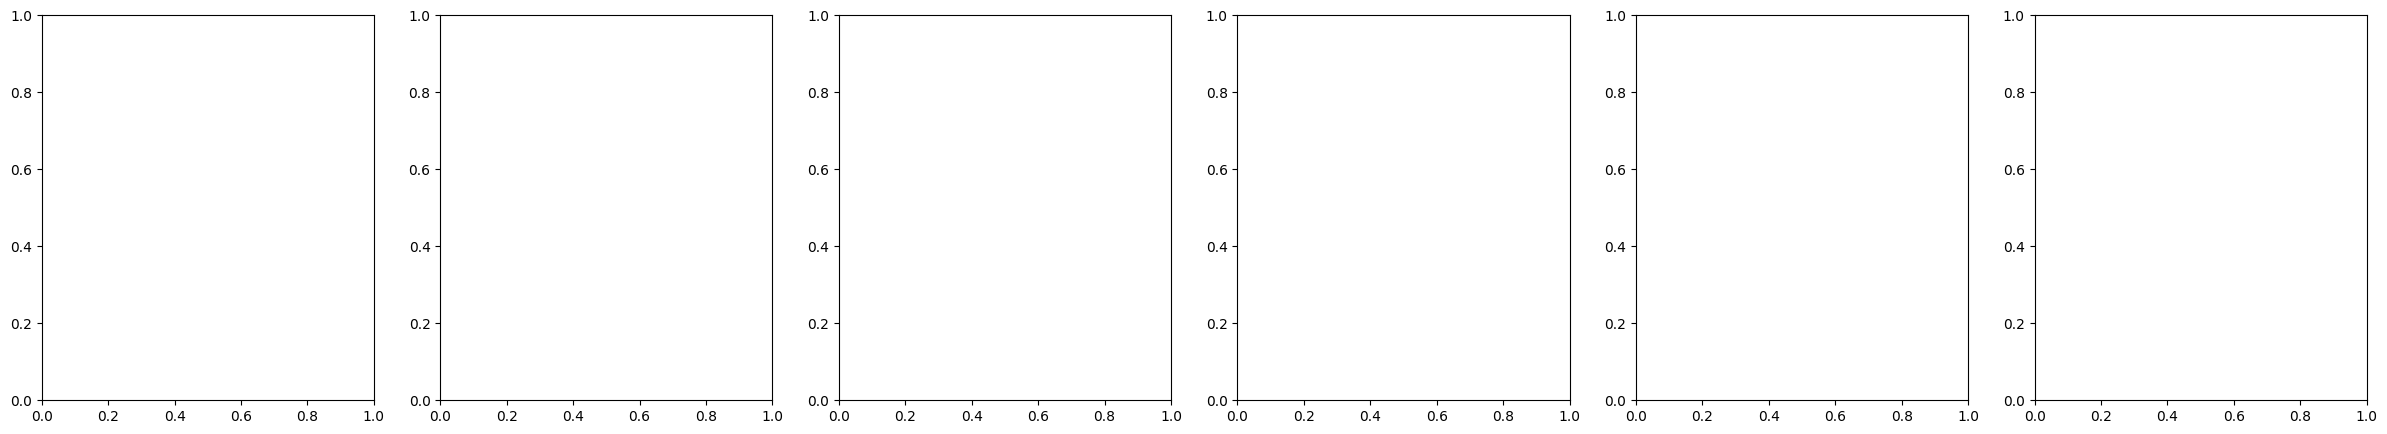

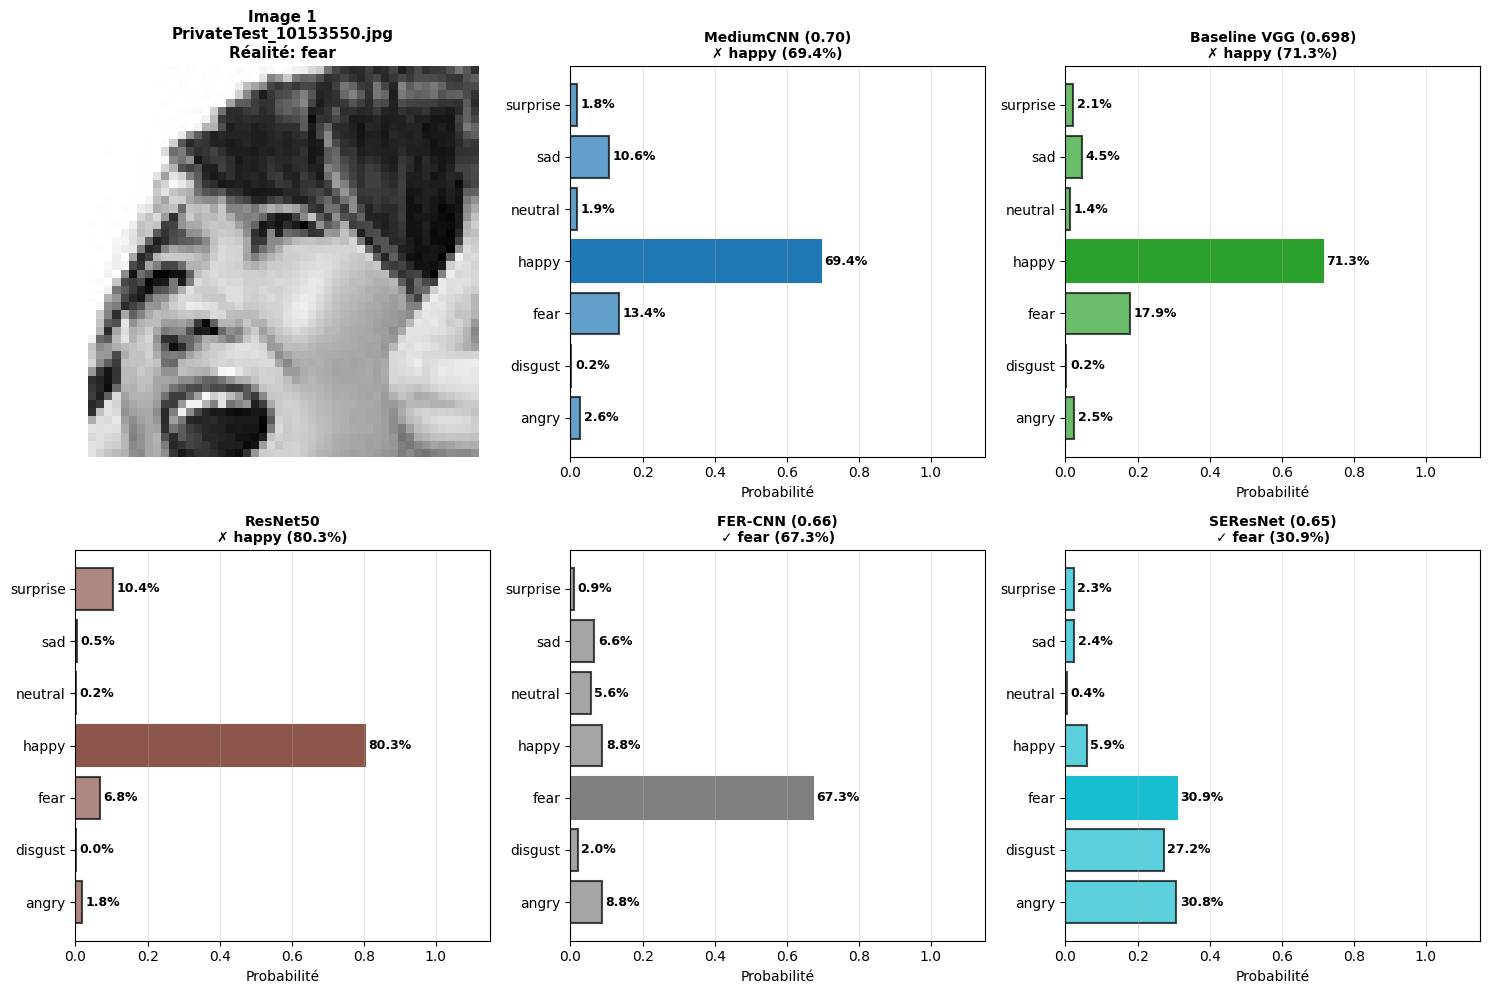

  Image 2: PrivateTest_10254684.jpg
    ✗ MediumCNN (0.70): angry (87.0%)
    ✓ Baseline VGG (0.698): fear (46.1%)
    ✗ ResNet50: angry (48.1%)
    ✗ FER-CNN (0.66): sad (38.8%)
    ✗ SEResNet (0.65): angry (53.8%)


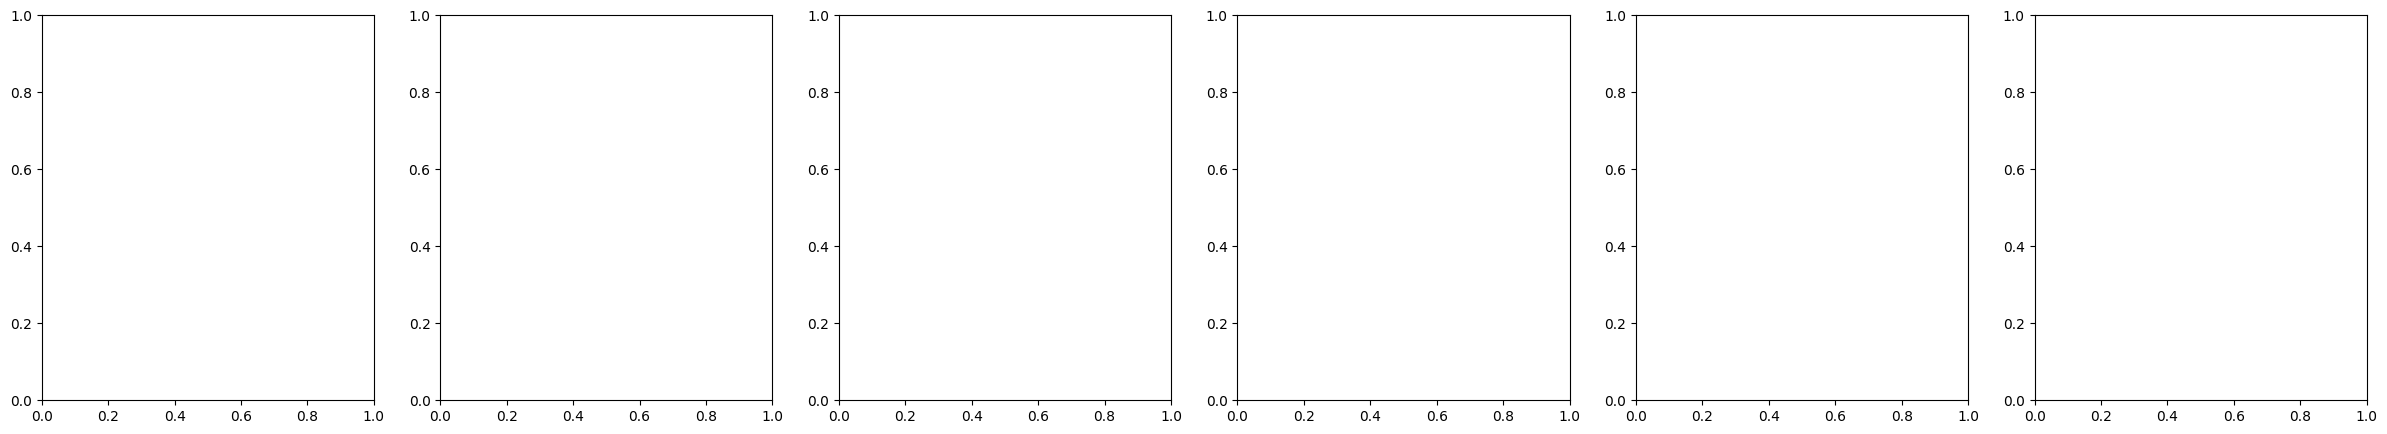

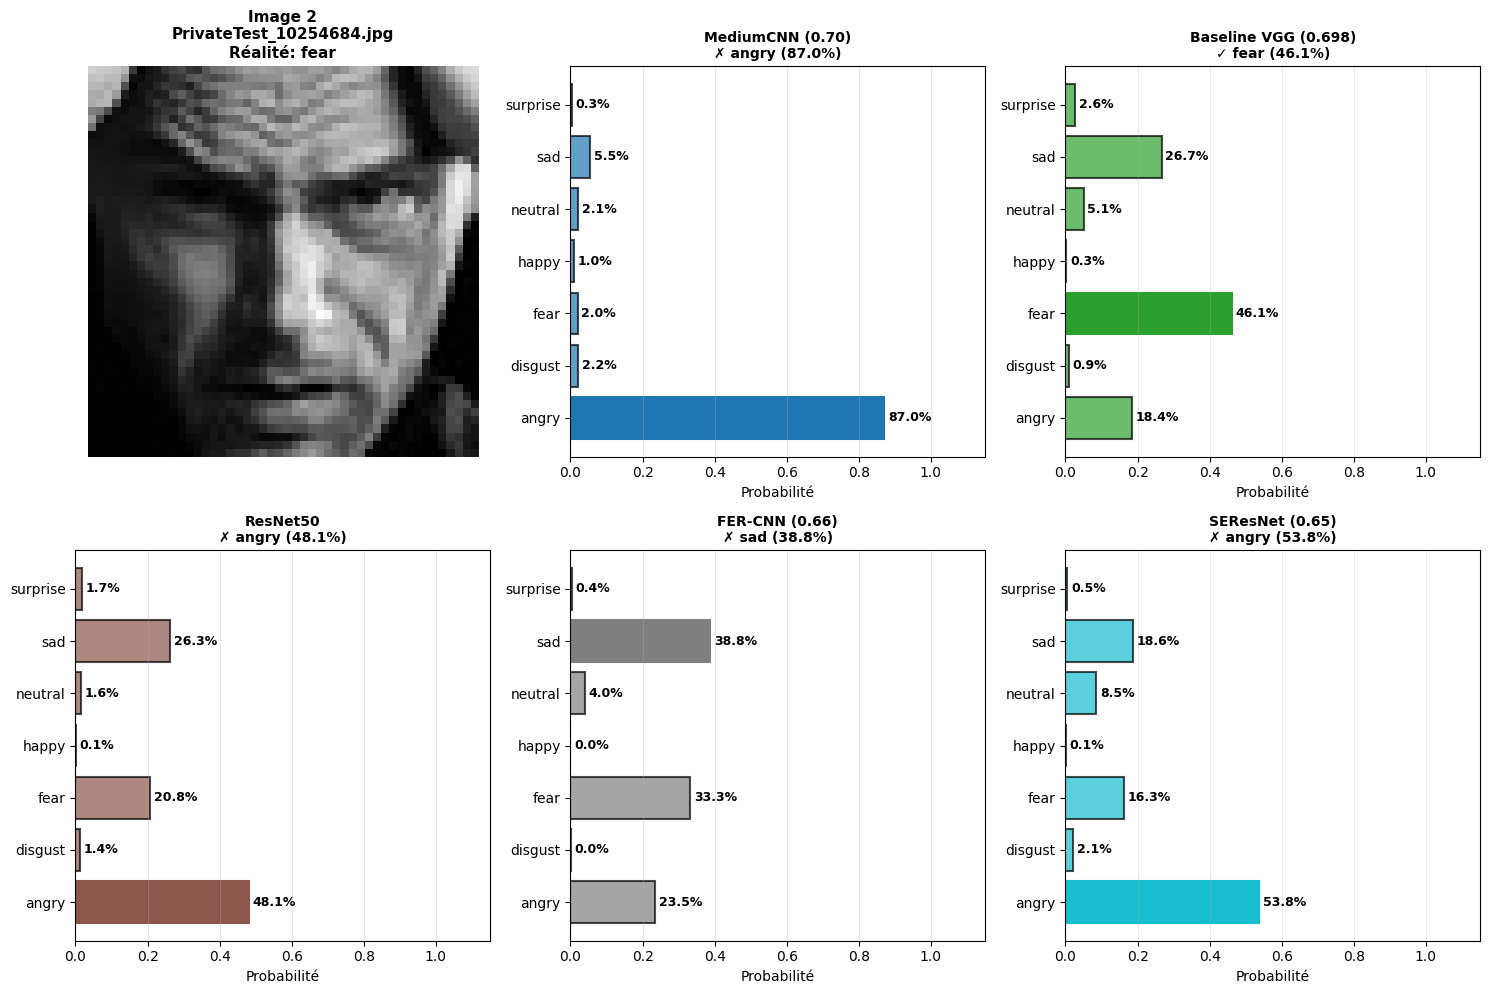

  Image 3: PrivateTest_10306709.jpg
    ✗ MediumCNN (0.70): angry (43.7%)
    ✓ Baseline VGG (0.698): fear (44.4%)
    ✗ ResNet50: surprise (37.1%)
    ✓ FER-CNN (0.66): fear (46.4%)
    ✓ SEResNet (0.65): fear (44.6%)


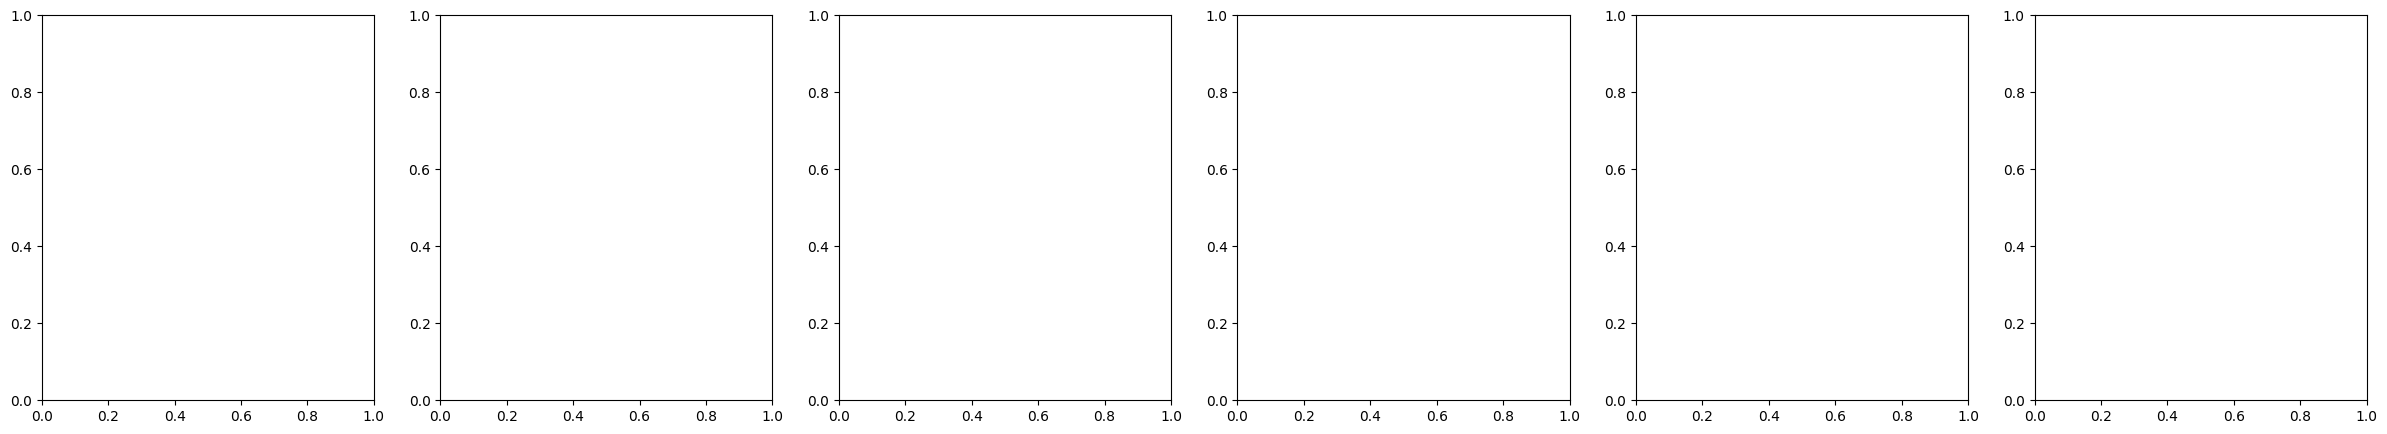

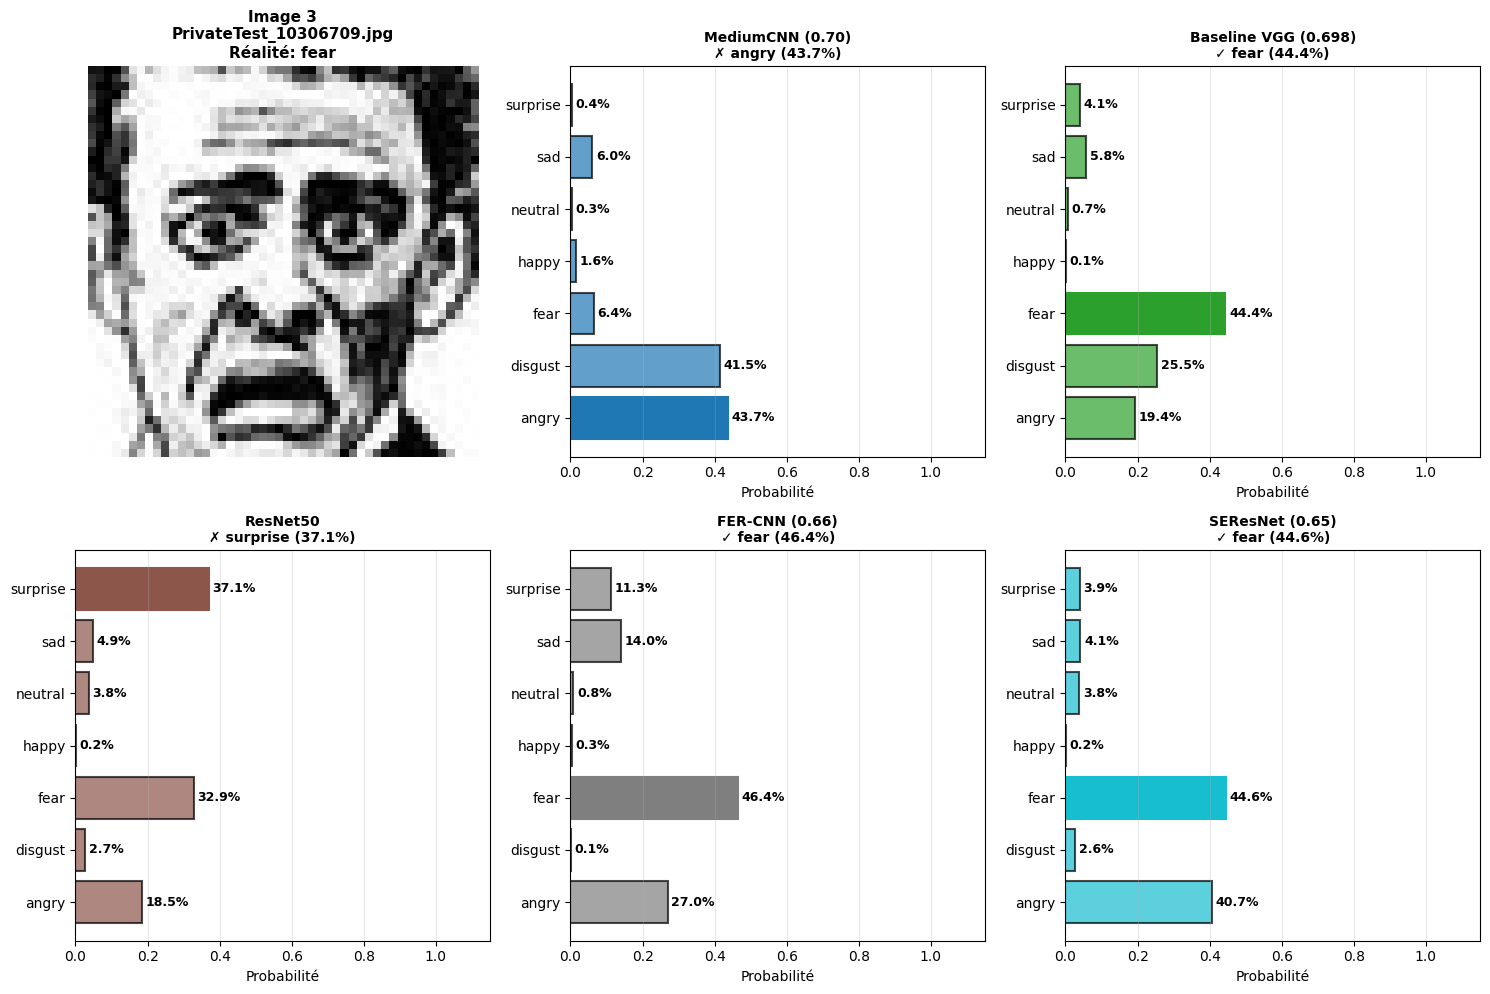


  Résumé (fear):
    MediumCNN (0.70): 0/3 correct (0%)
    Baseline VGG (0.698): 2/3 correct (67%)
    ResNet50: 0/3 correct (0%)
    FER-CNN (0.66): 2/3 correct (67%)
    SEResNet (0.65): 2/3 correct (67%)

📁 Émotion réelle: HAPPY (1774 images)
--------------------------------------------------------------------------------
  Image 1: PrivateTest_10077120.jpg
    ✓ MediumCNN (0.70): happy (97.8%)
    ✓ Baseline VGG (0.698): happy (94.1%)
    ✓ ResNet50: happy (99.9%)
    ✓ FER-CNN (0.66): happy (99.6%)
    ✓ SEResNet (0.65): happy (98.5%)


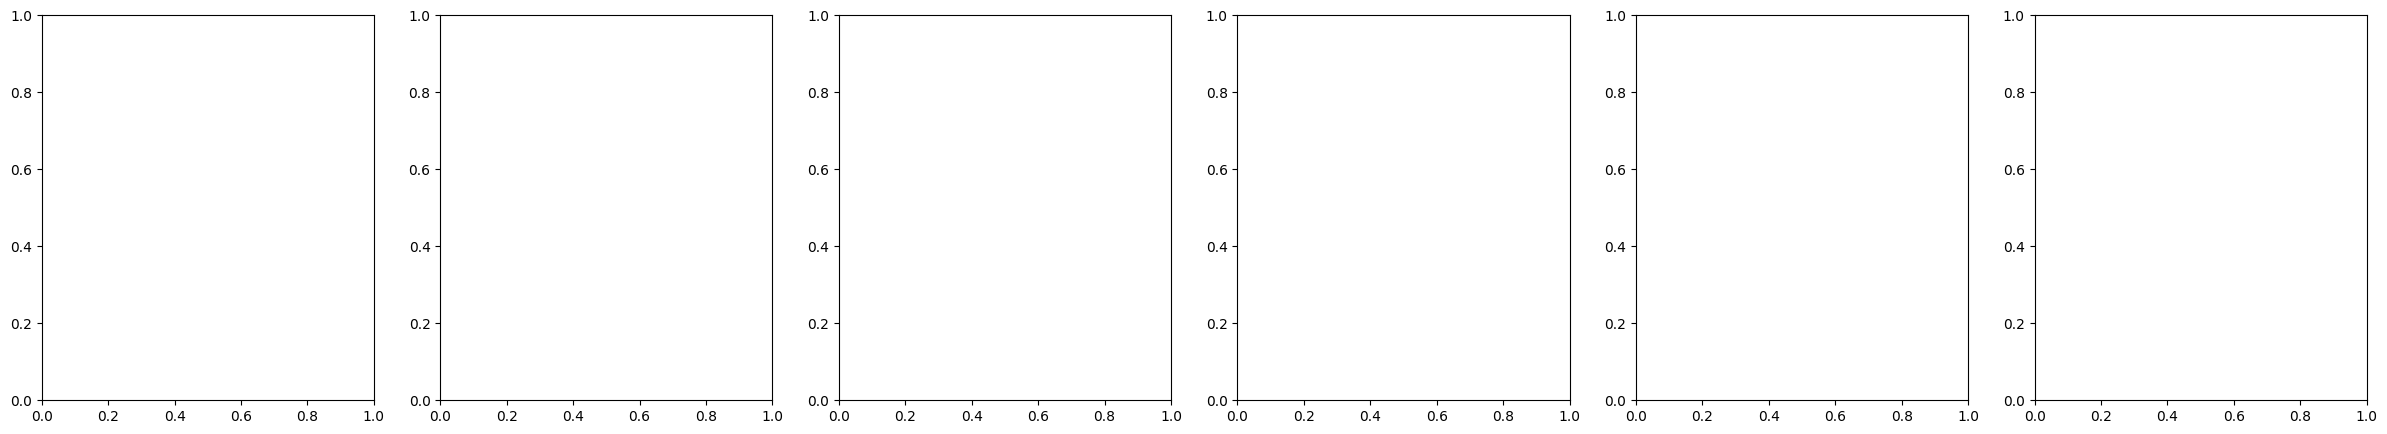

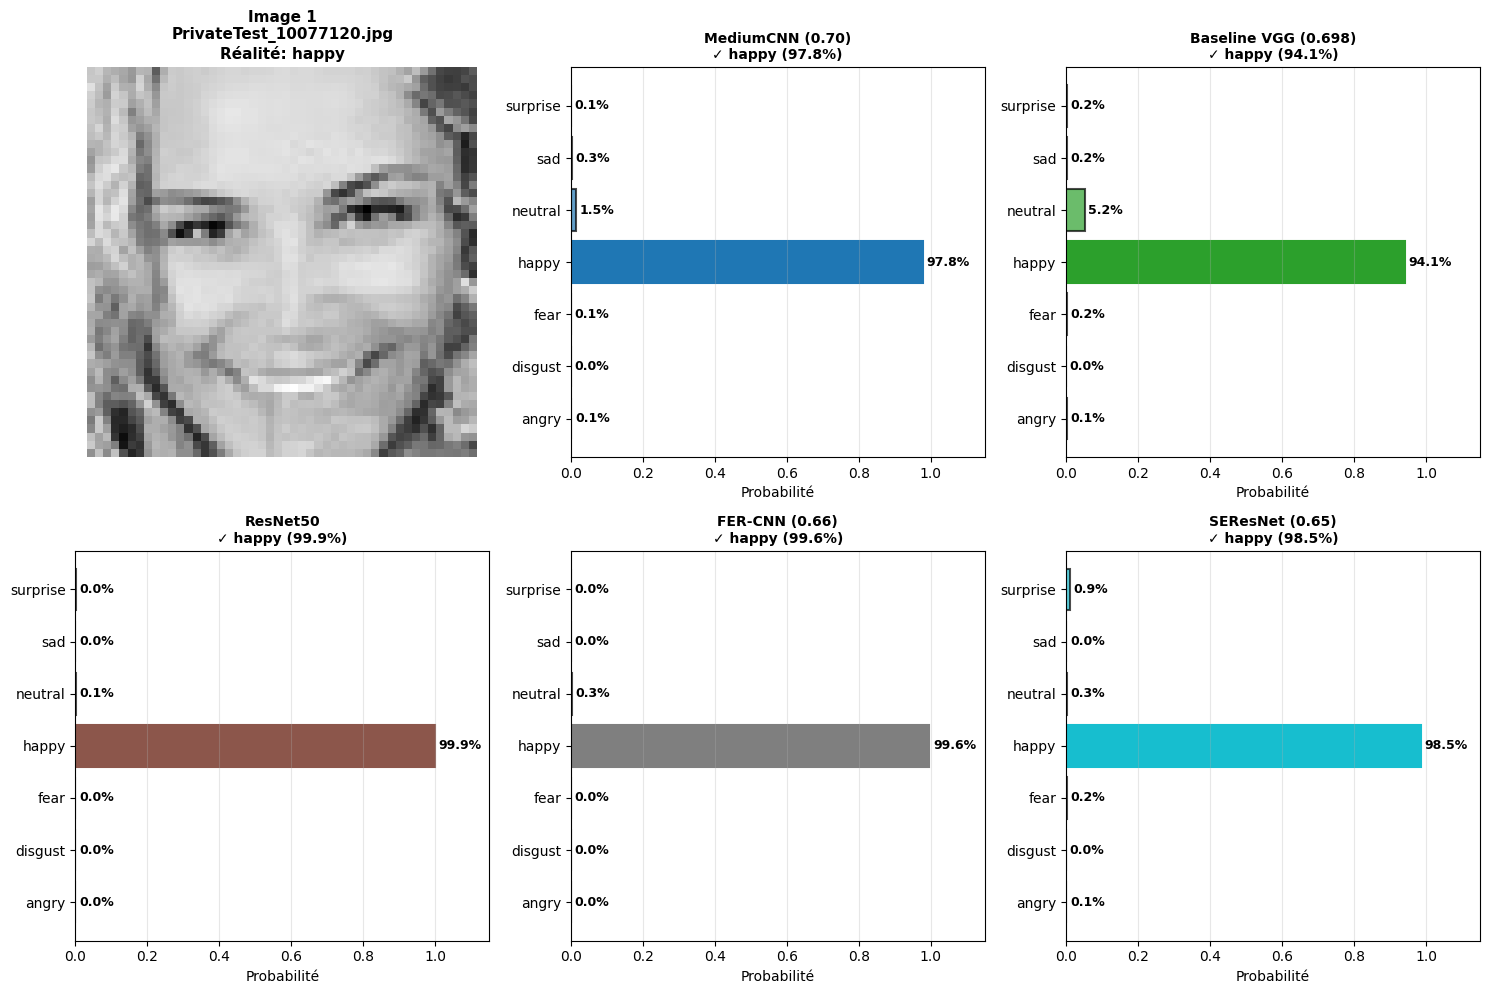

  Image 2: PrivateTest_10470092.jpg
    ✓ MediumCNN (0.70): happy (94.3%)
    ✗ Baseline VGG (0.698): angry (34.0%)
    ✓ ResNet50: happy (85.5%)
    ✗ FER-CNN (0.66): neutral (66.5%)
    ✓ SEResNet (0.65): happy (59.2%)


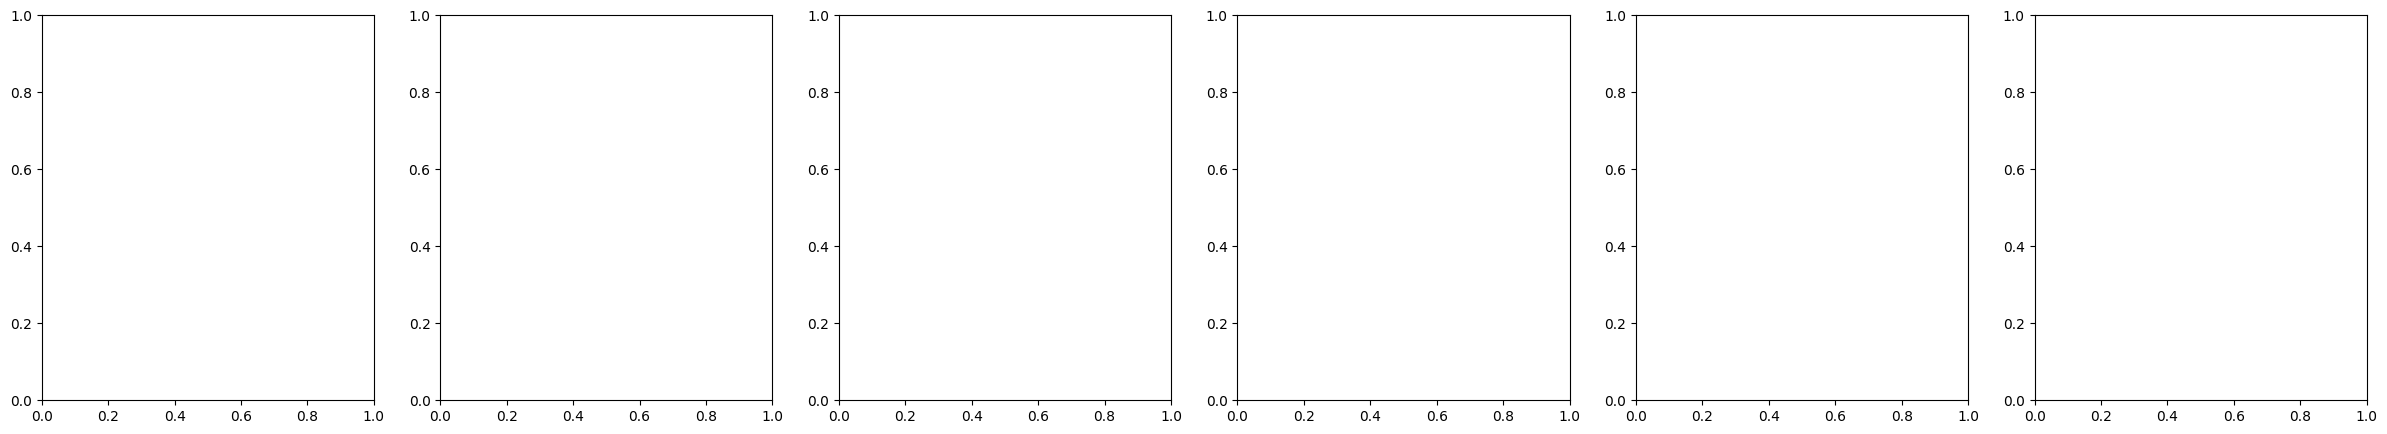

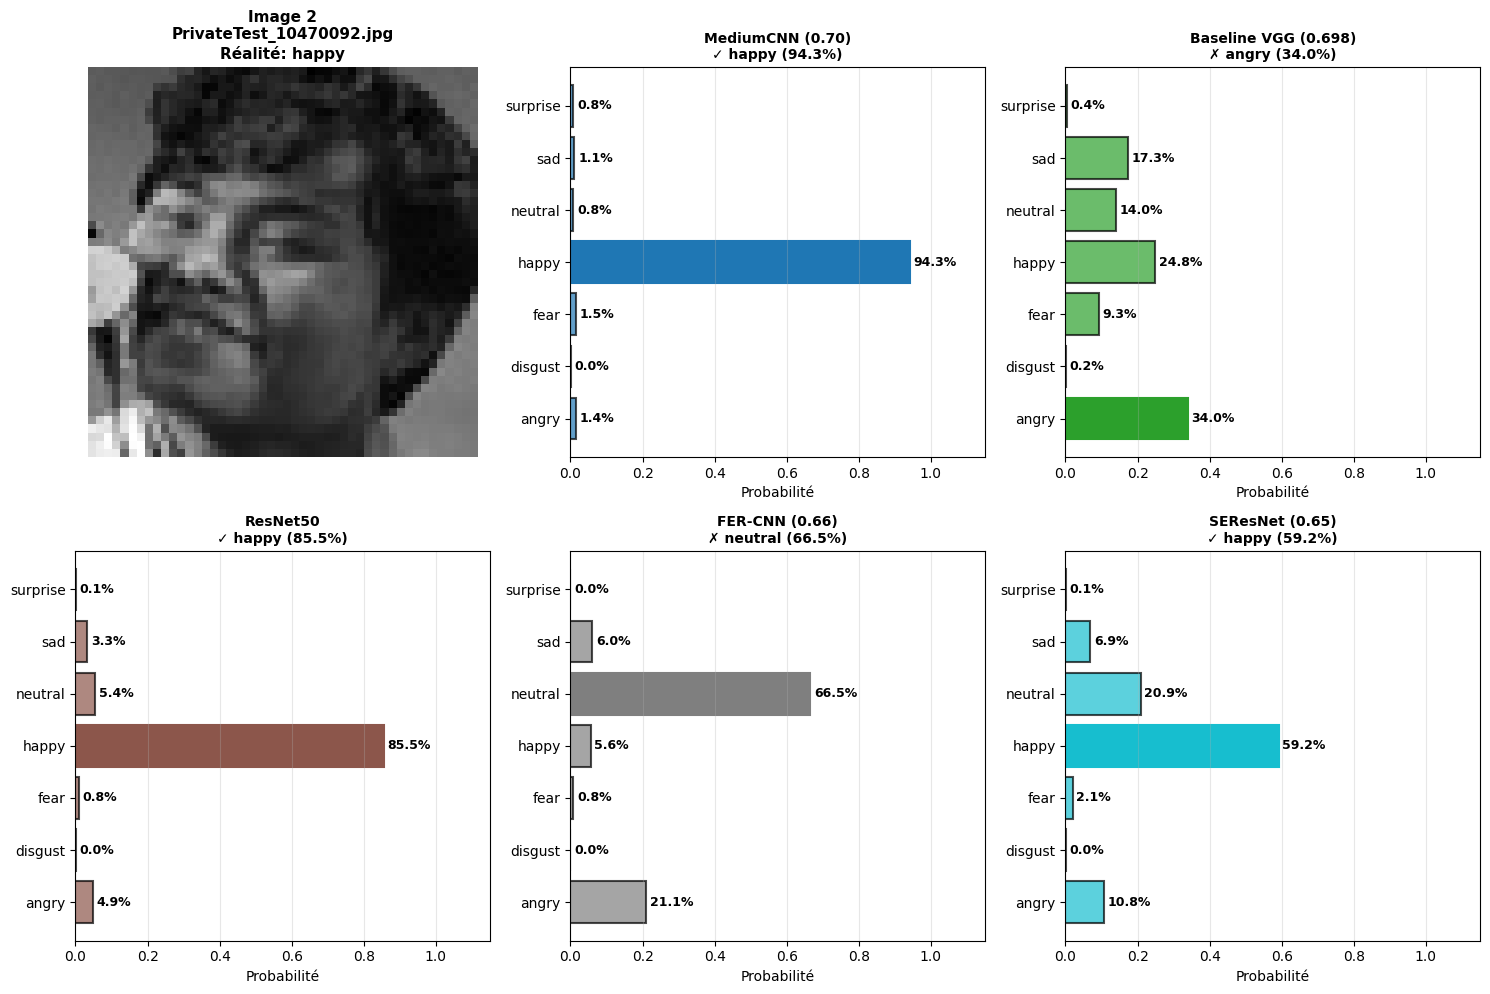

  Image 3: PrivateTest_10513598.jpg
    ✓ MediumCNN (0.70): happy (72.6%)
    ✓ Baseline VGG (0.698): happy (82.1%)
    ✓ ResNet50: happy (76.0%)
    ✓ FER-CNN (0.66): happy (69.5%)
    ✓ SEResNet (0.65): happy (69.8%)


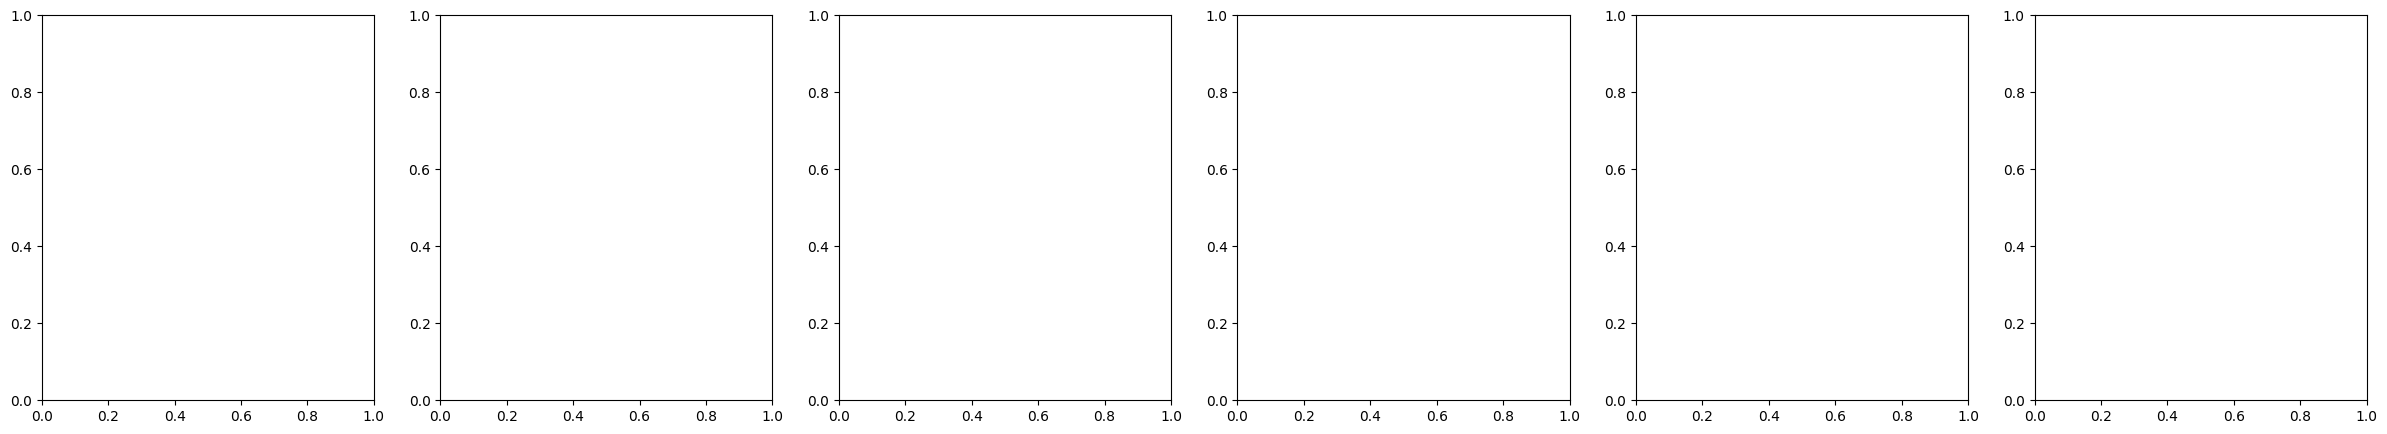

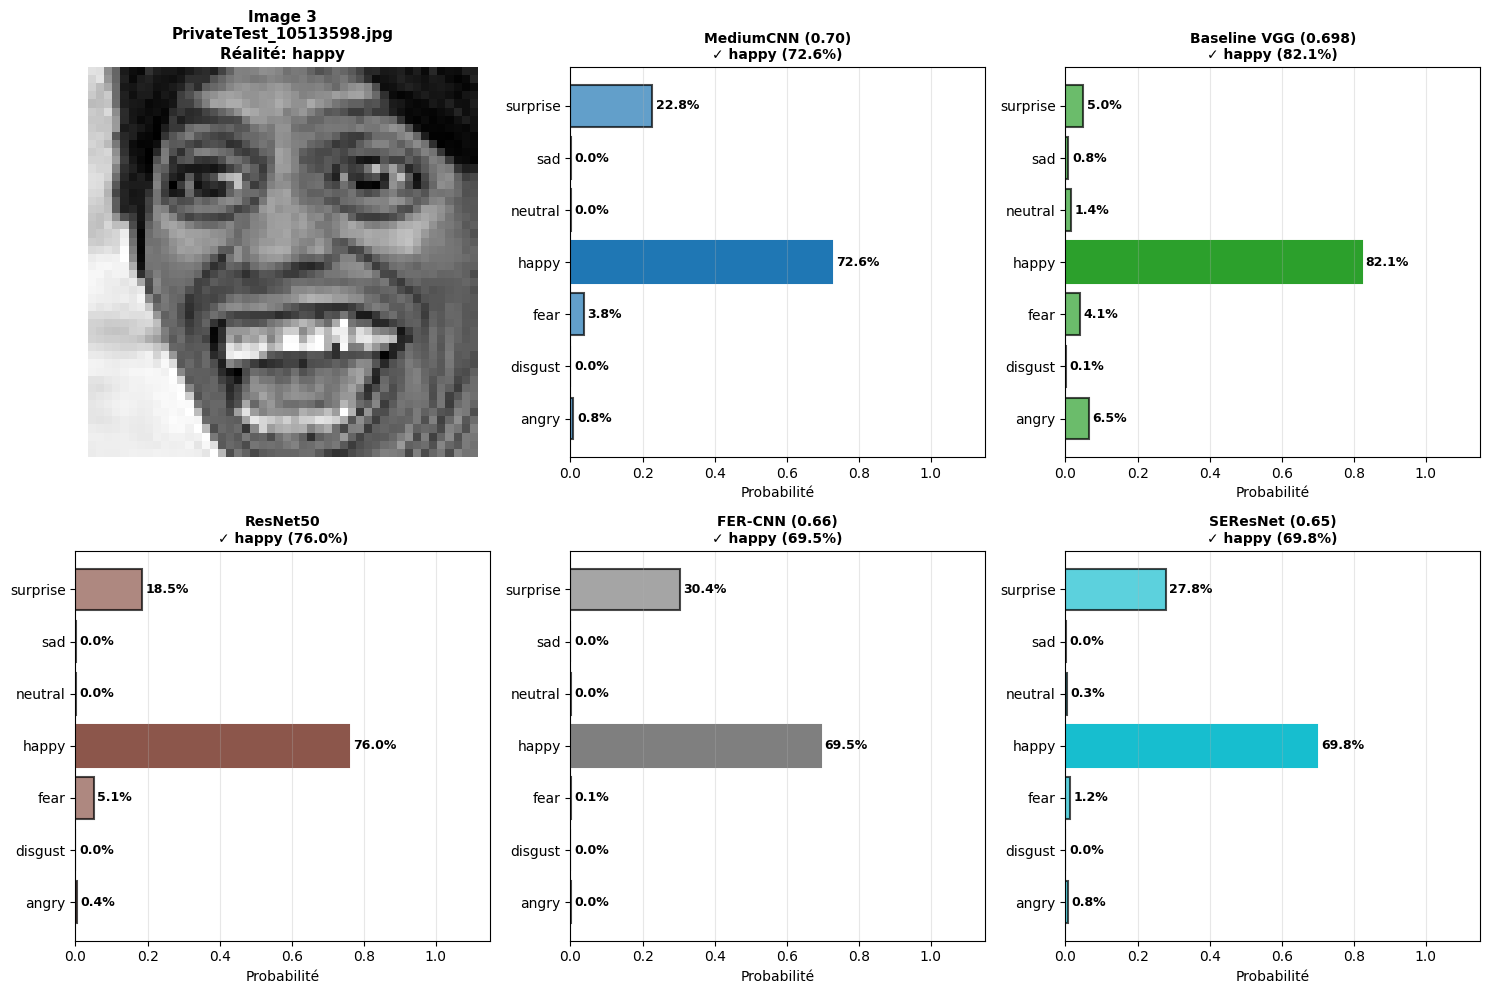


  Résumé (happy):
    MediumCNN (0.70): 3/3 correct (100%)
    Baseline VGG (0.698): 2/3 correct (67%)
    ResNet50: 3/3 correct (100%)
    FER-CNN (0.66): 2/3 correct (67%)
    SEResNet (0.65): 3/3 correct (100%)

📁 Émotion réelle: NEUTRAL (1233 images)
--------------------------------------------------------------------------------
  Image 1: PrivateTest_10086748.jpg
    ✓ MediumCNN (0.70): neutral (27.3%)
    ✓ Baseline VGG (0.698): neutral (66.0%)
    ✗ ResNet50: surprise (47.4%)
    ✓ FER-CNN (0.66): neutral (78.5%)
    ✓ SEResNet (0.65): neutral (66.8%)


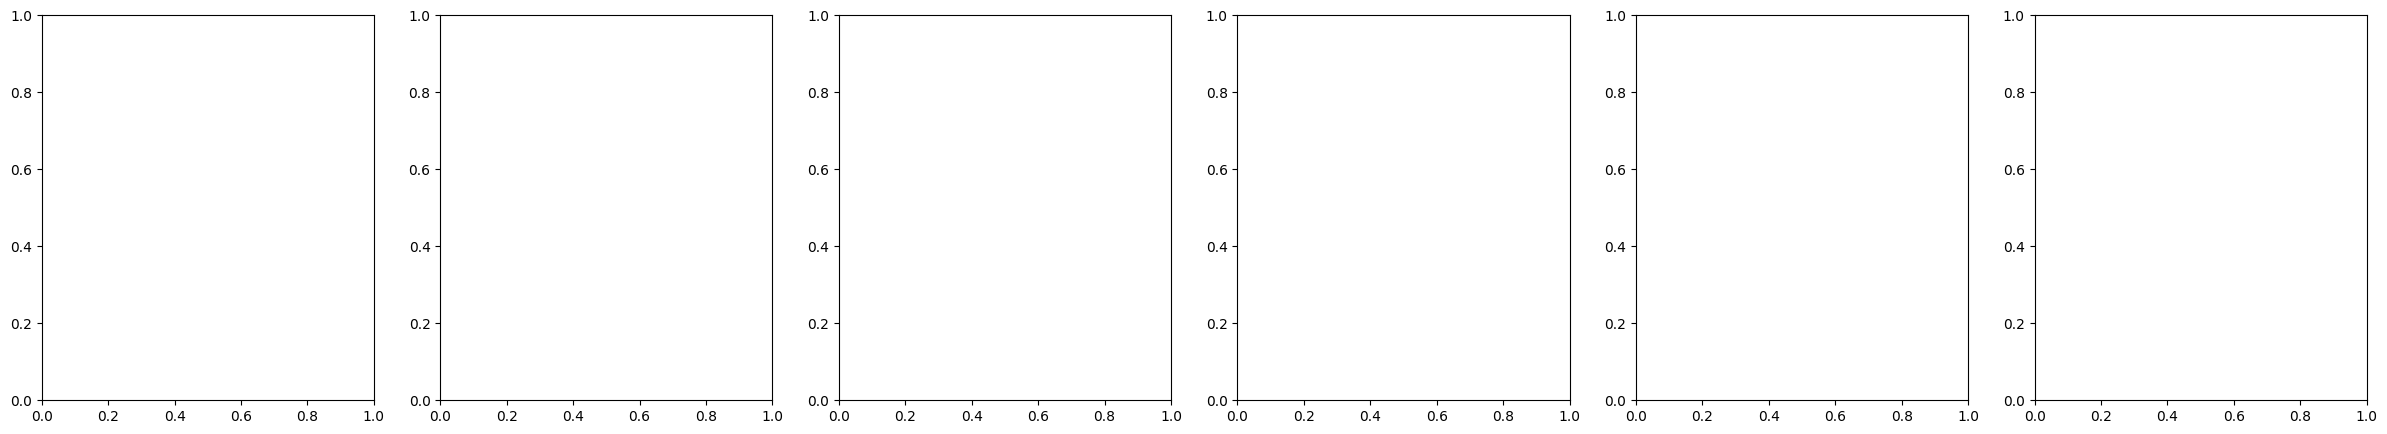

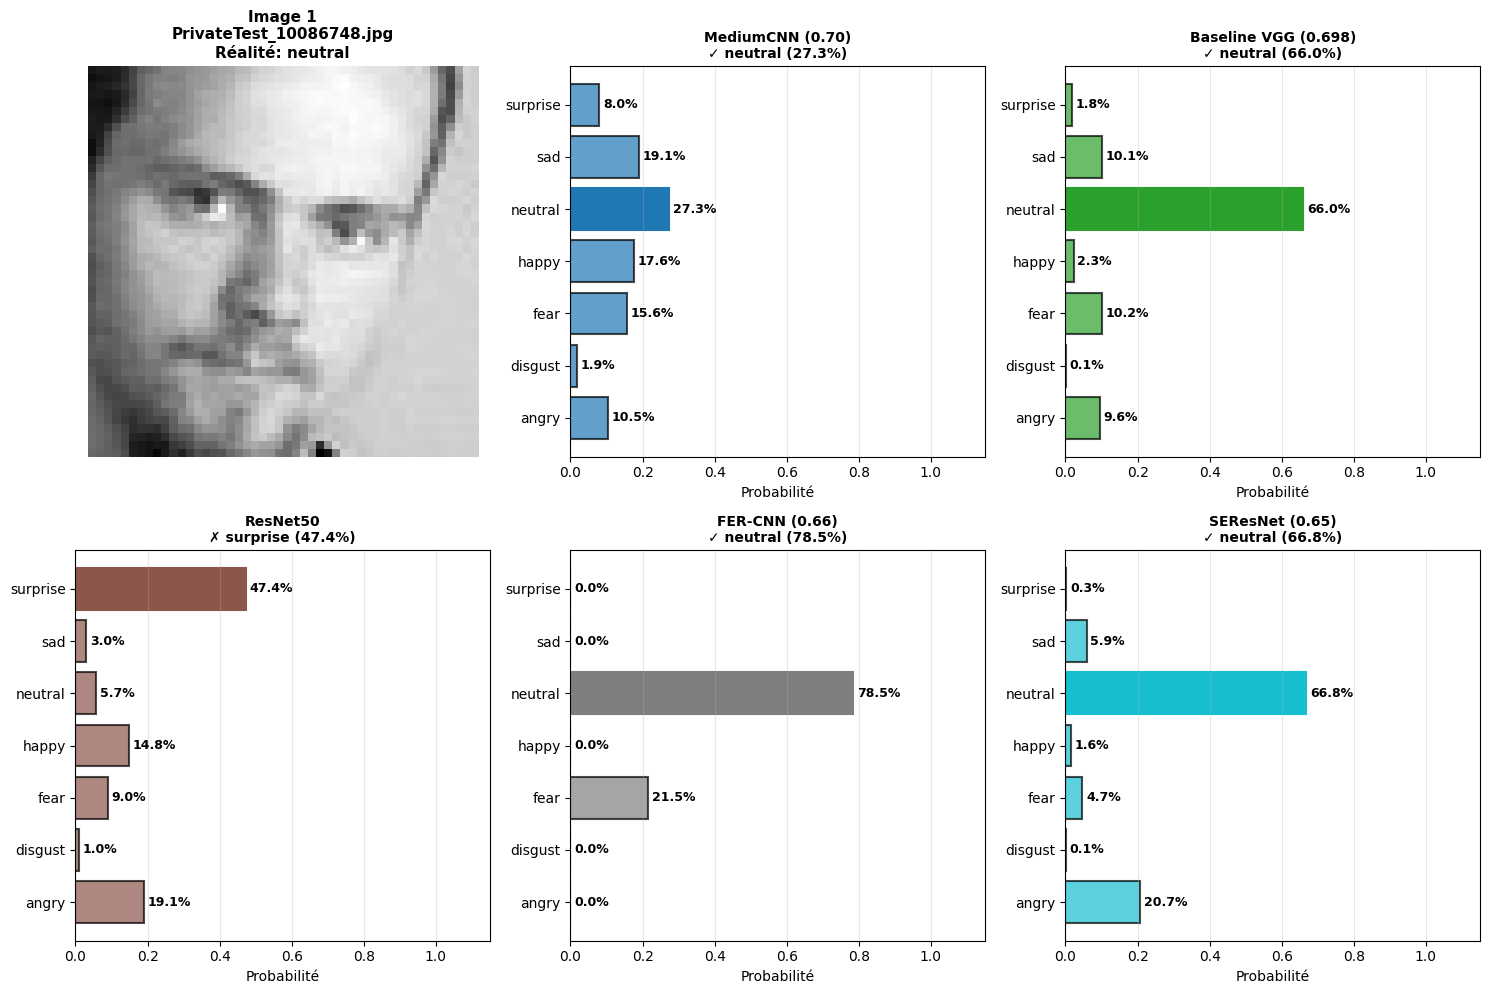

  Image 2: PrivateTest_10767287.jpg
    ✗ MediumCNN (0.70): sad (52.9%)
    ✓ Baseline VGG (0.698): neutral (60.0%)
    ✓ ResNet50: neutral (56.6%)
    ✓ FER-CNN (0.66): neutral (57.6%)
    ✓ SEResNet (0.65): neutral (87.4%)


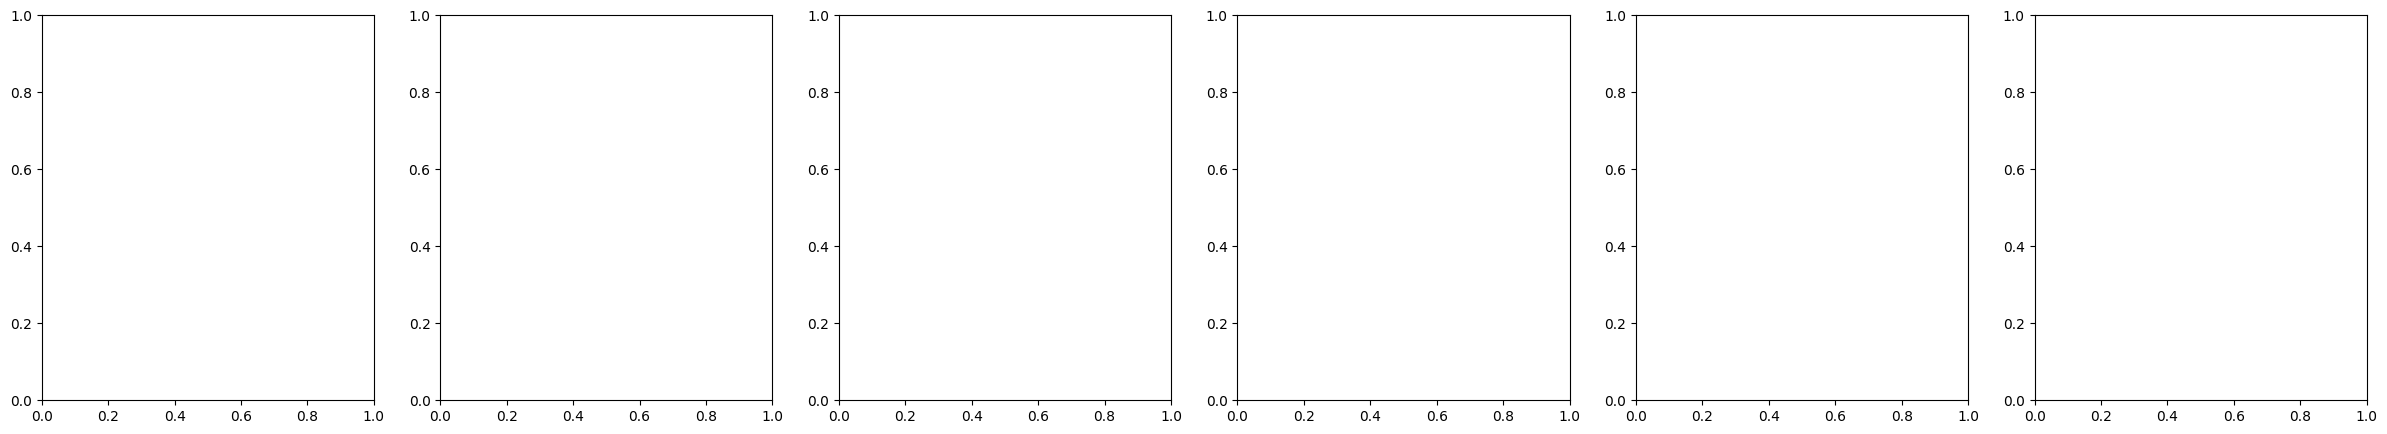

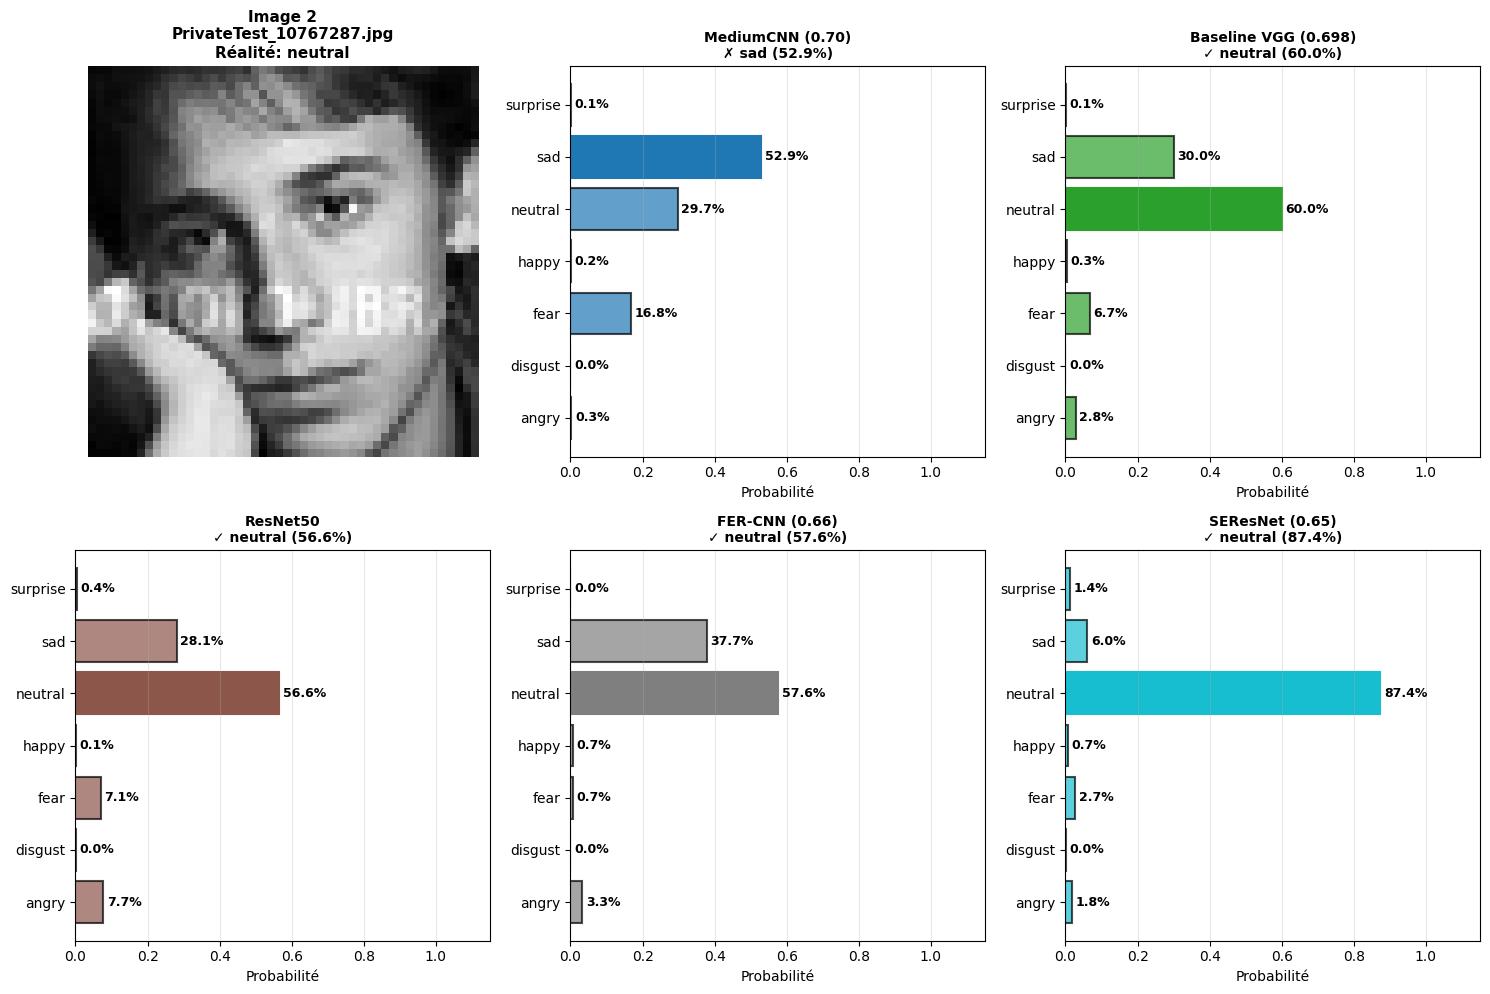

  Image 3: PrivateTest_11123843.jpg
    ✓ MediumCNN (0.70): neutral (93.0%)
    ✓ Baseline VGG (0.698): neutral (48.9%)
    ✓ ResNet50: neutral (51.1%)
    ✓ FER-CNN (0.66): neutral (99.0%)
    ✓ SEResNet (0.65): neutral (74.6%)


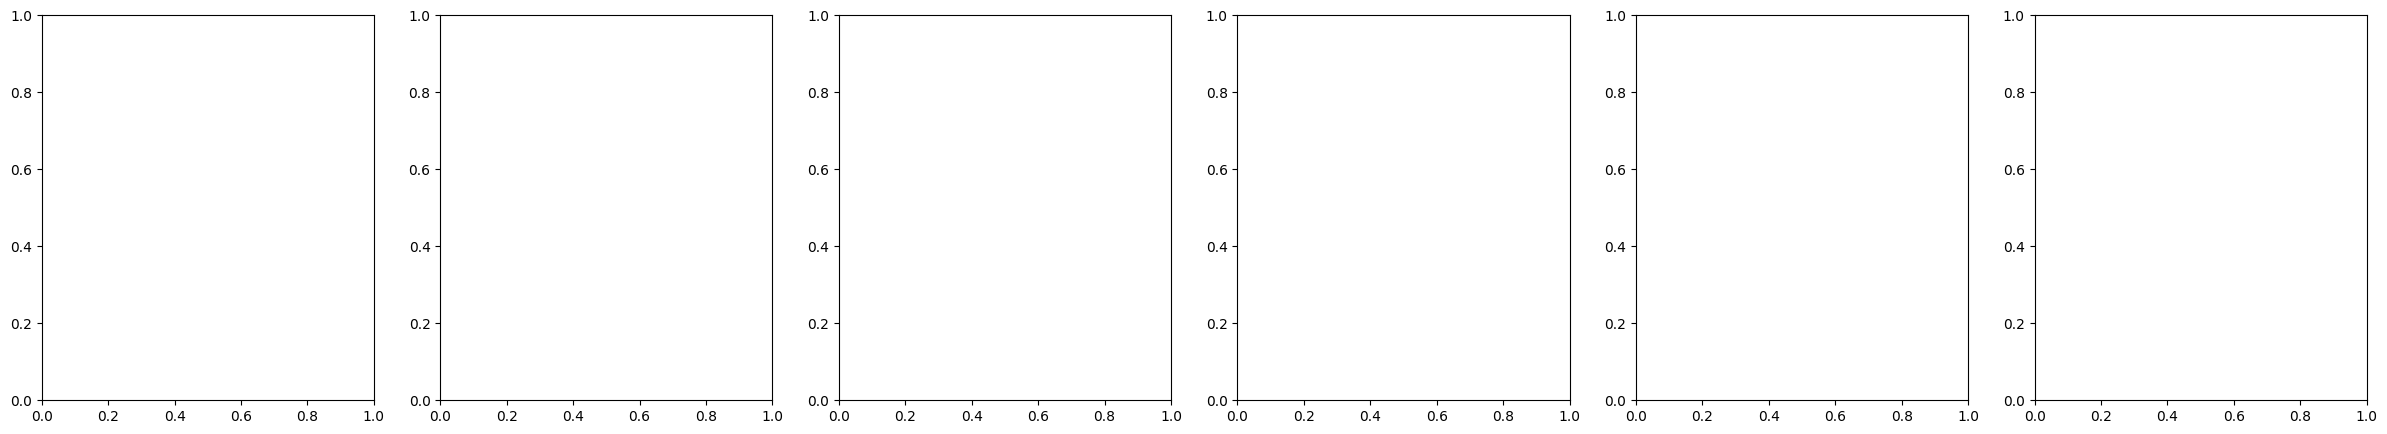

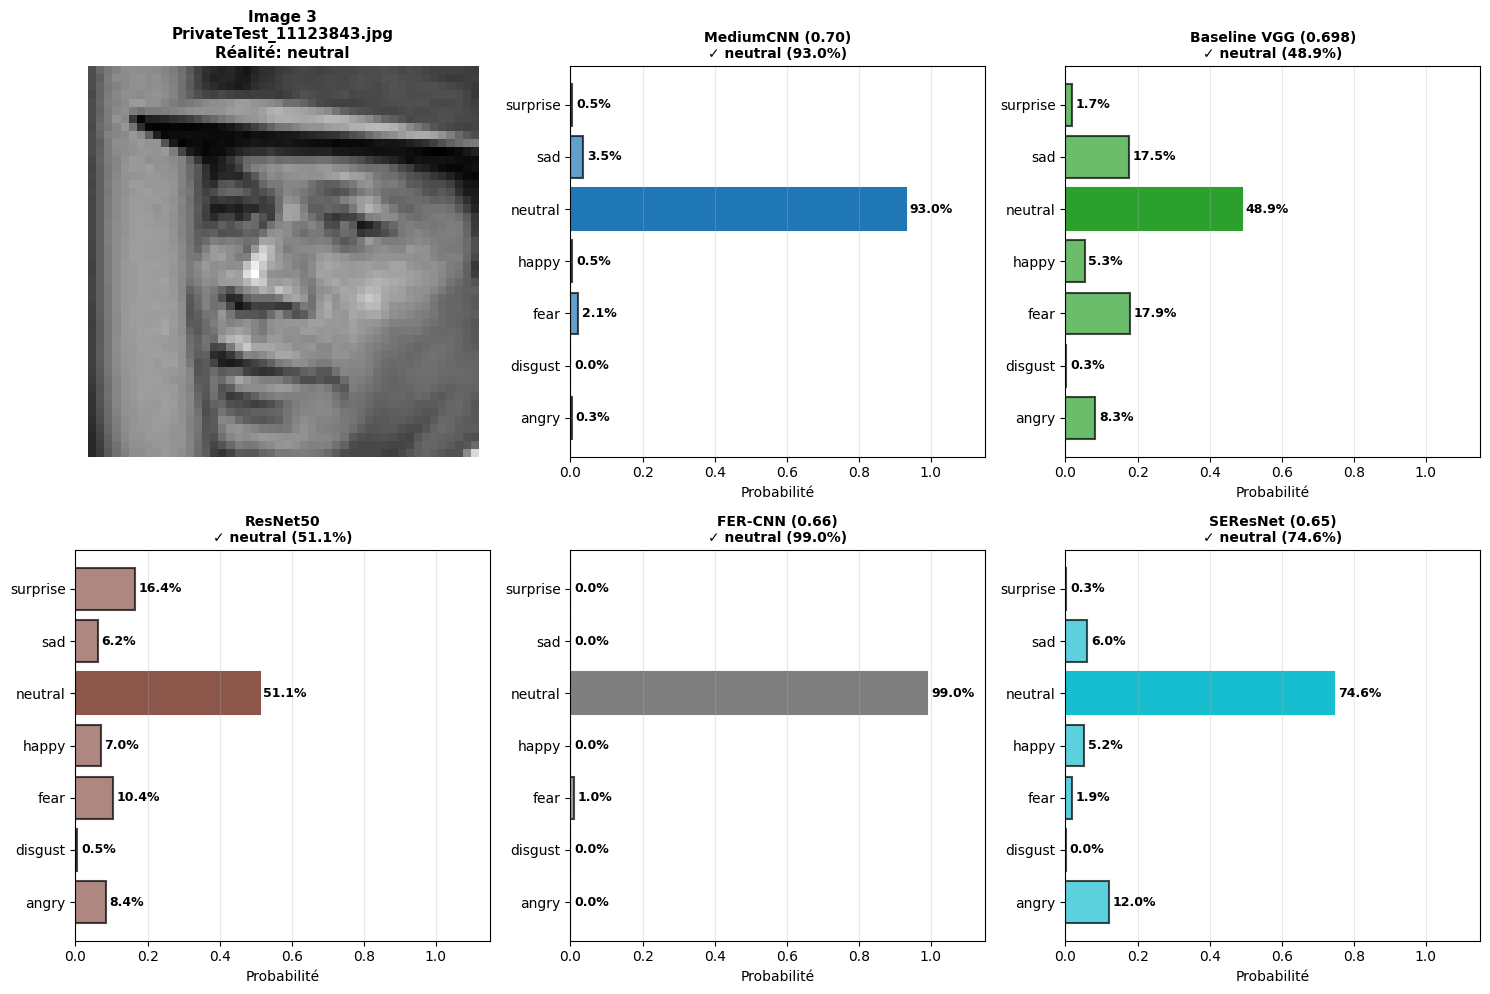


  Résumé (neutral):
    MediumCNN (0.70): 2/3 correct (67%)
    Baseline VGG (0.698): 3/3 correct (100%)
    ResNet50: 2/3 correct (67%)
    FER-CNN (0.66): 3/3 correct (100%)
    SEResNet (0.65): 3/3 correct (100%)

📁 Émotion réelle: SAD (1247 images)
--------------------------------------------------------------------------------
  Image 1: PrivateTest_10247676.jpg
    ✗ MediumCNN (0.70): disgust (79.2%)
    ✗ Baseline VGG (0.698): angry (29.9%)
    ✗ ResNet50: fear (67.1%)
    ✓ FER-CNN (0.66): sad (50.2%)
    ✗ SEResNet (0.65): neutral (31.1%)


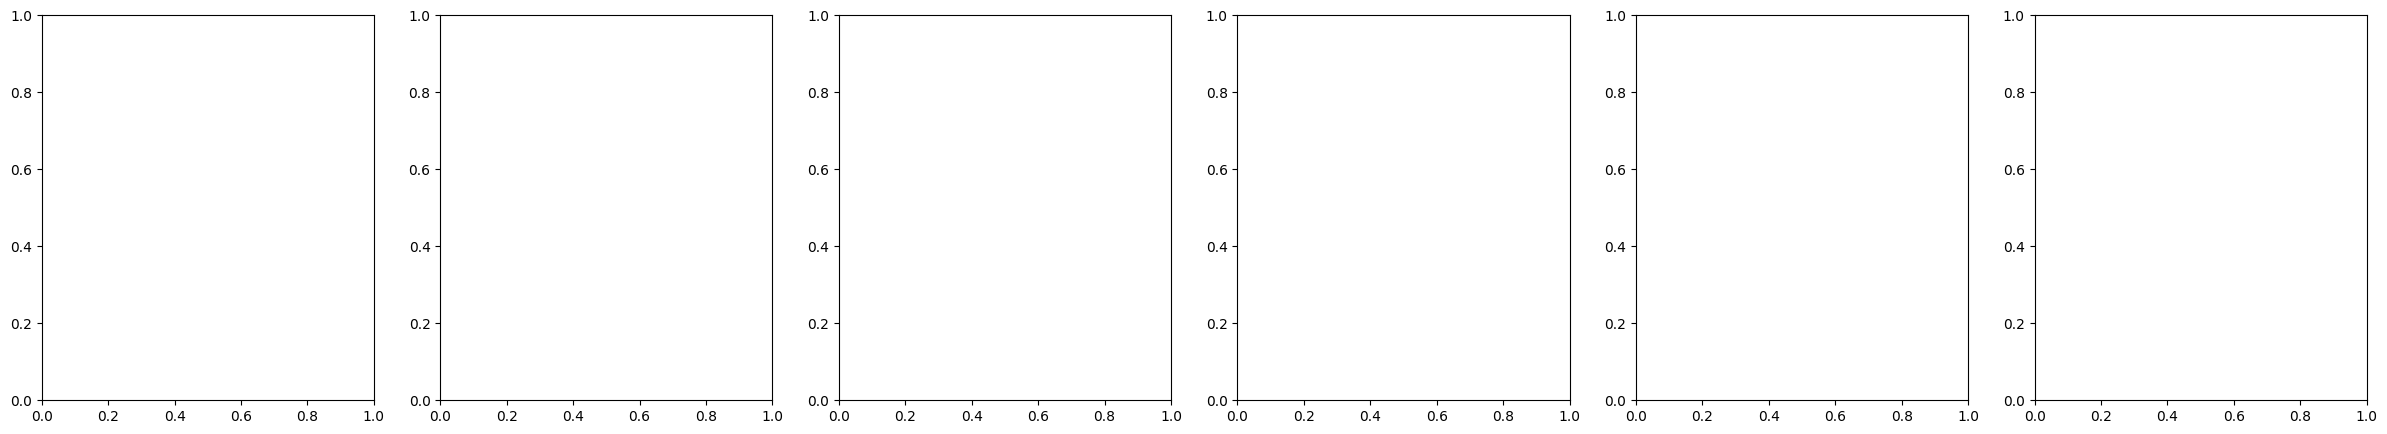

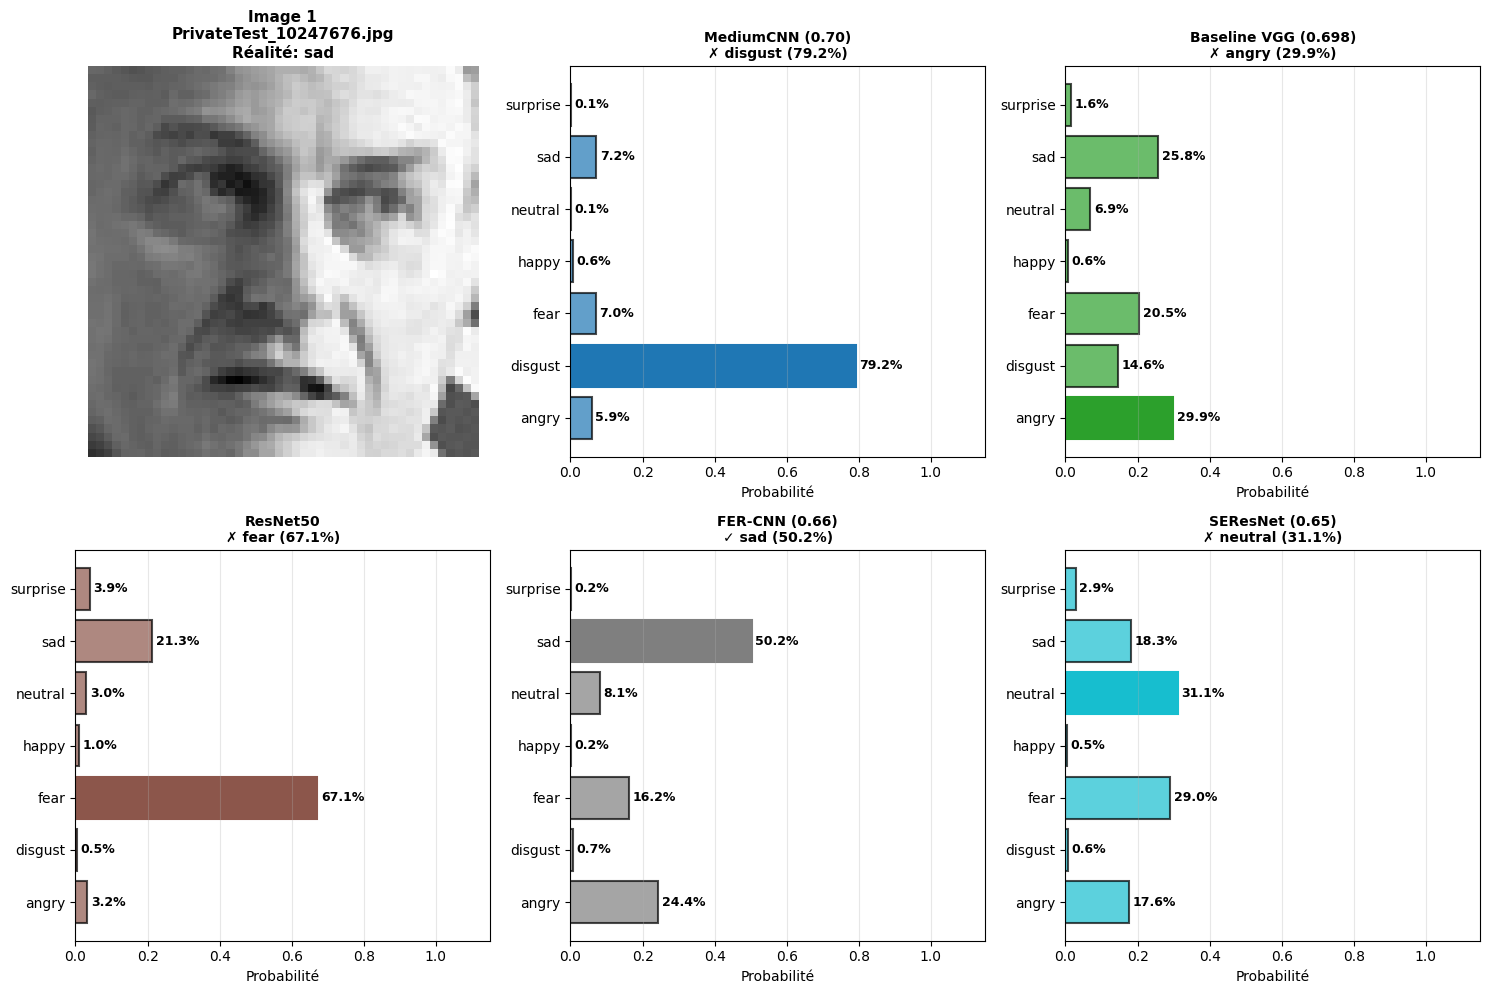

  Image 2: PrivateTest_10455506.jpg
    ✗ MediumCNN (0.70): angry (63.4%)
    ✗ Baseline VGG (0.698): angry (82.9%)
    ✓ ResNet50: sad (53.7%)
    ✗ FER-CNN (0.66): angry (62.3%)
    ✗ SEResNet (0.65): angry (57.2%)


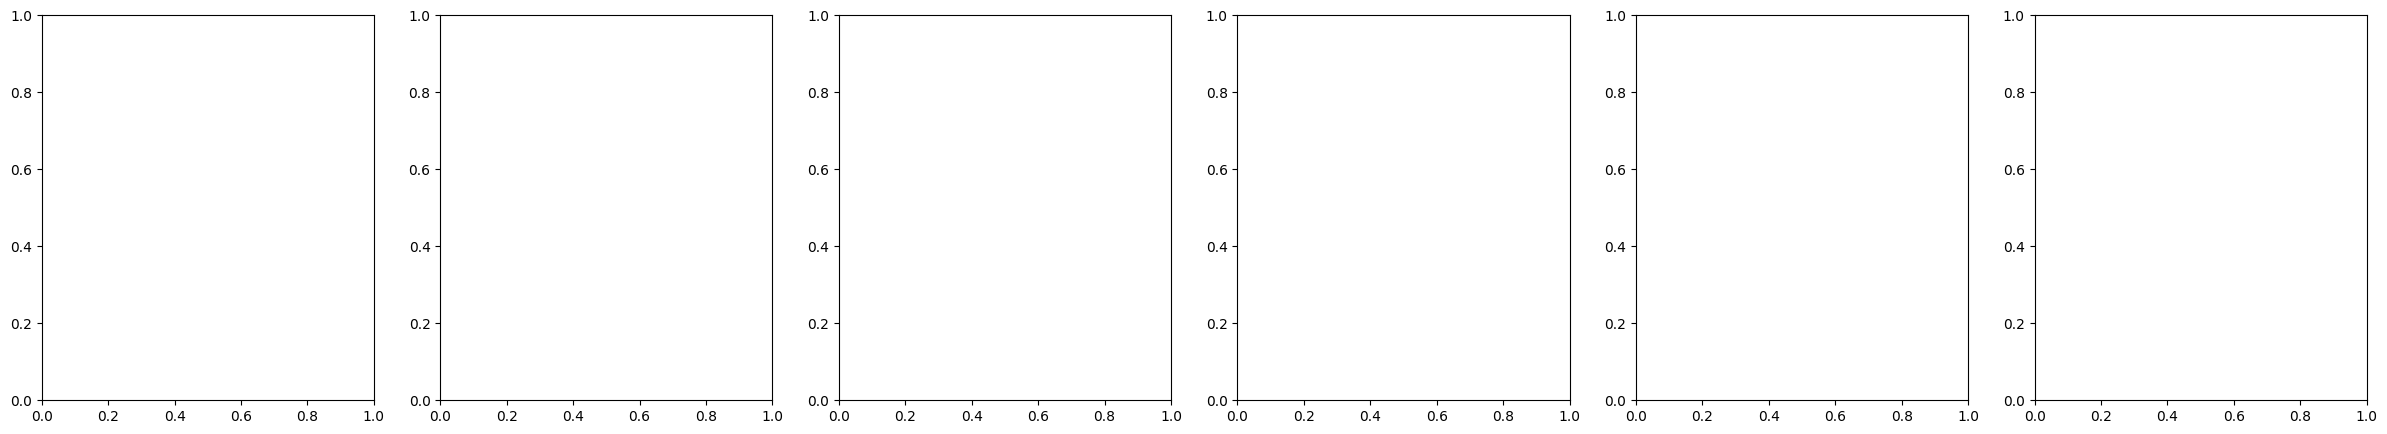

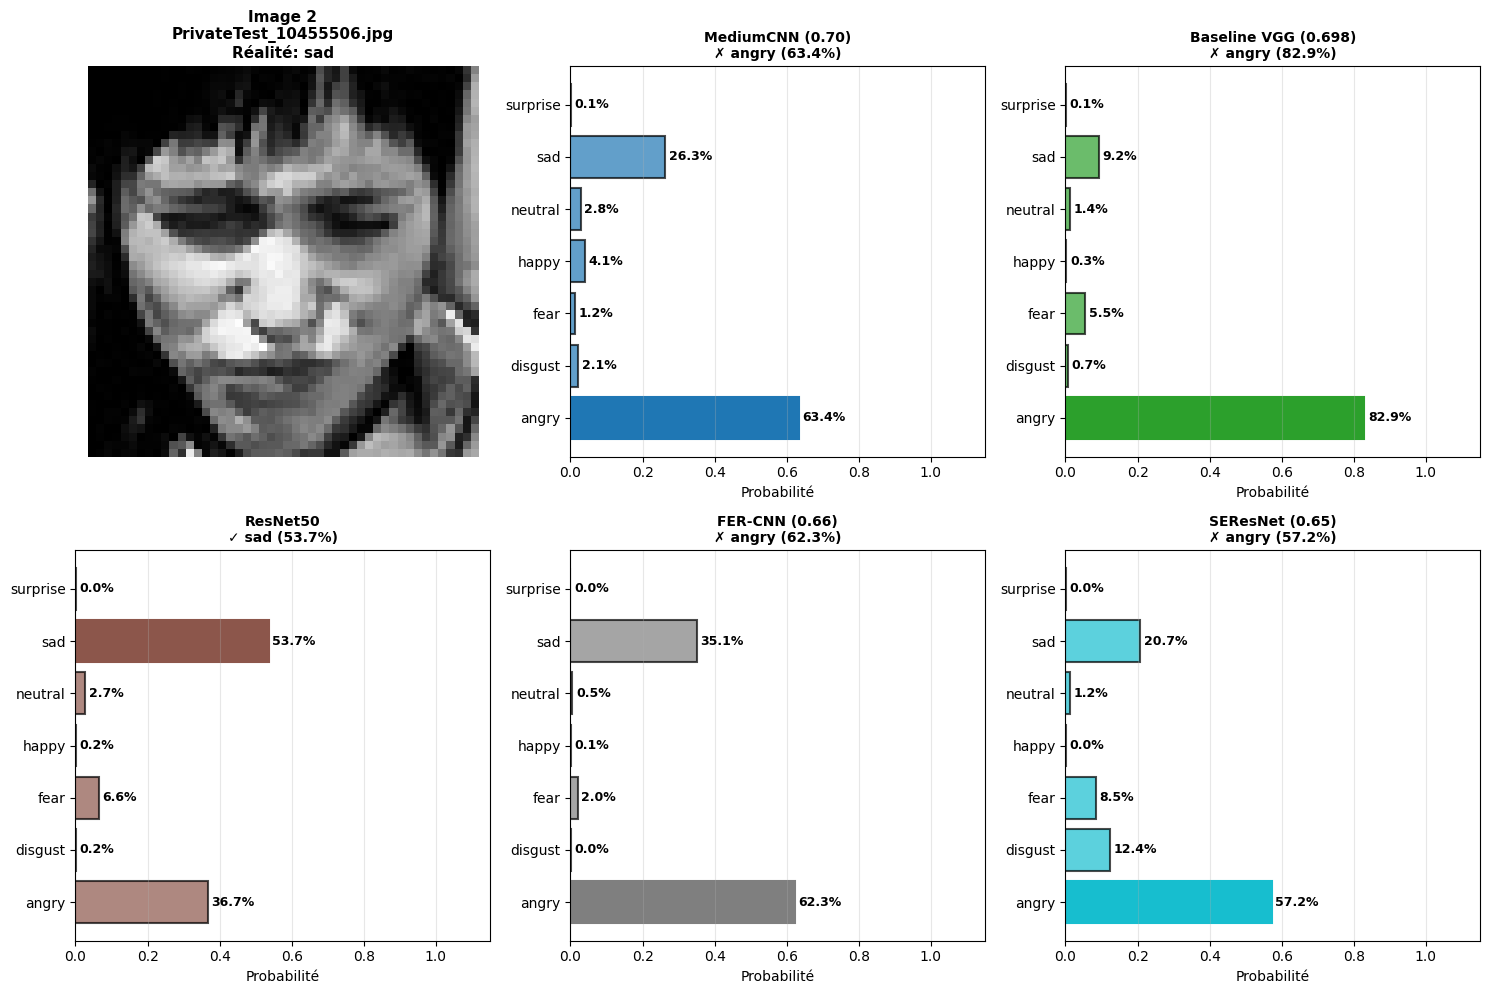

  Image 3: PrivateTest_10658656.jpg
    ✗ MediumCNN (0.70): fear (41.7%)
    ✗ Baseline VGG (0.698): surprise (42.6%)
    ✗ ResNet50: surprise (53.5%)
    ✗ FER-CNN (0.66): surprise (46.6%)
    ✗ SEResNet (0.65): surprise (80.5%)


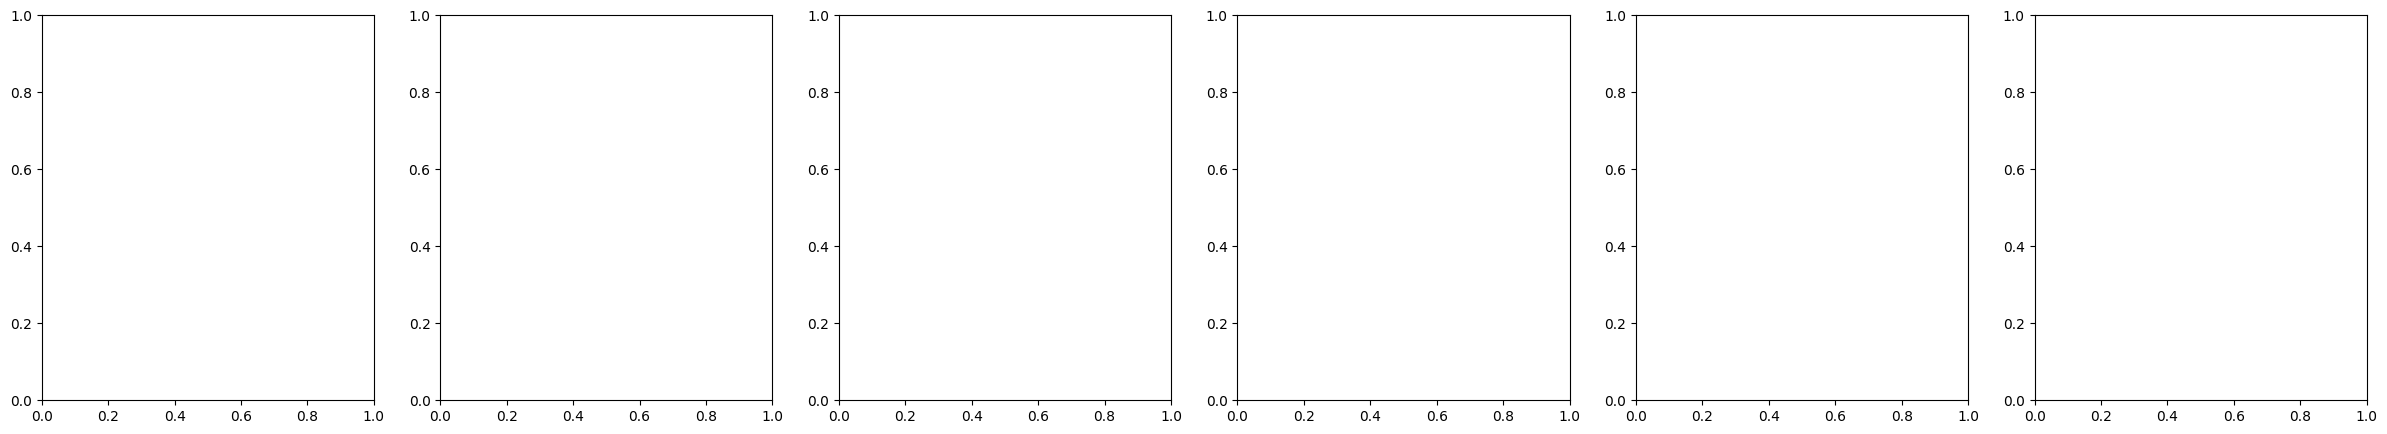

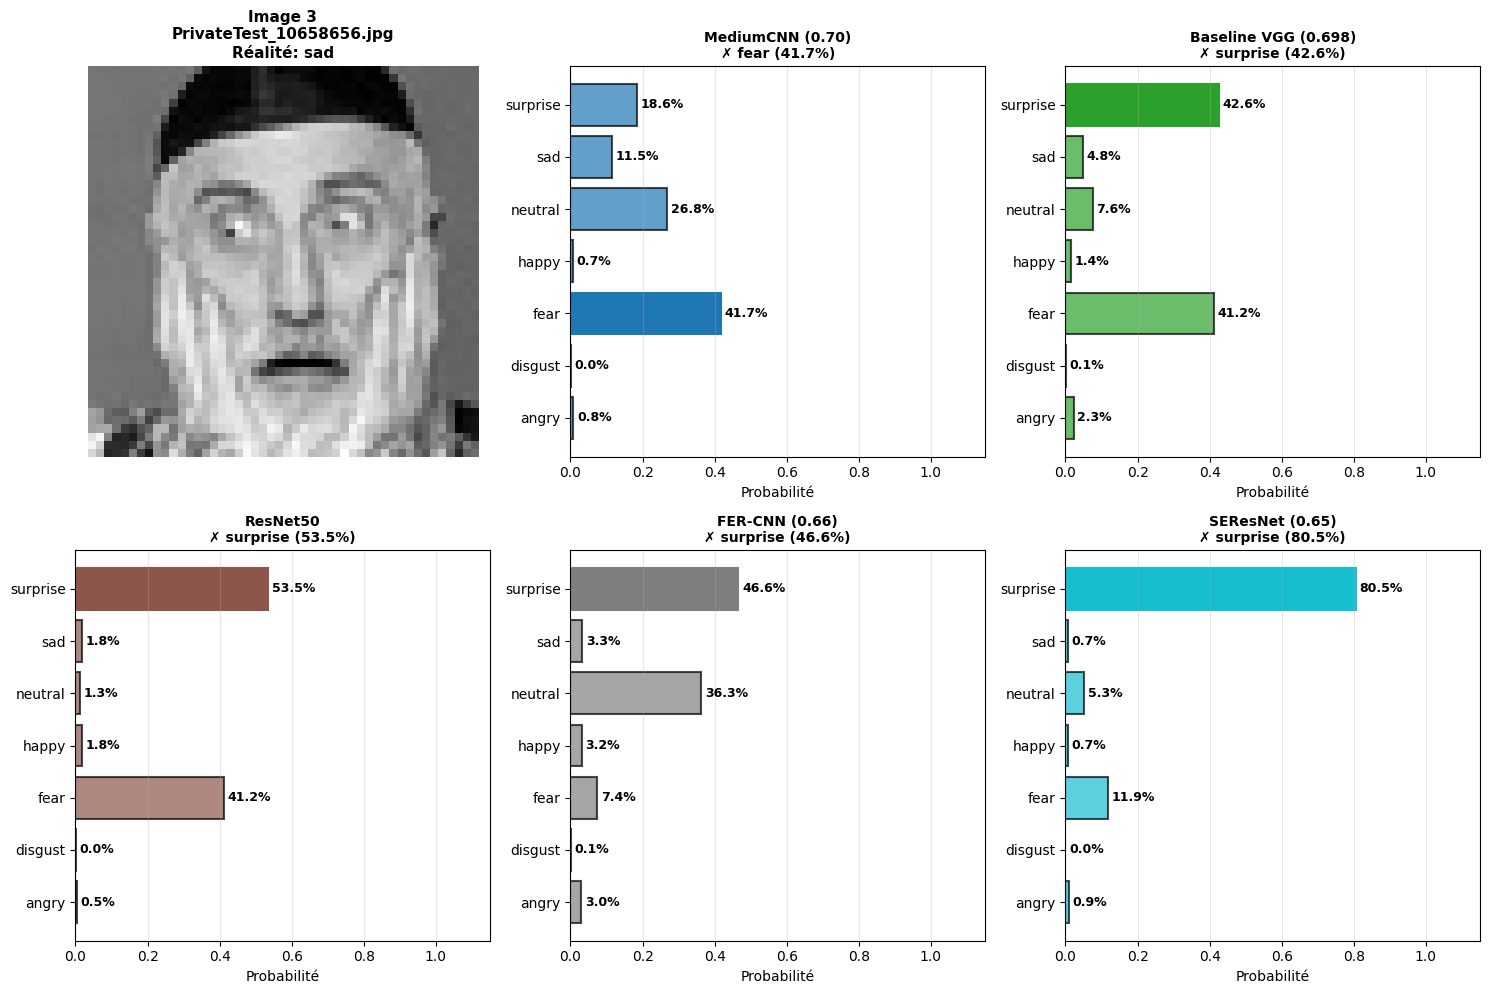


  Résumé (sad):
    MediumCNN (0.70): 0/3 correct (0%)
    Baseline VGG (0.698): 0/3 correct (0%)
    ResNet50: 1/3 correct (33%)
    FER-CNN (0.66): 1/3 correct (33%)
    SEResNet (0.65): 0/3 correct (0%)

📁 Émotion réelle: SURPRISE (831 images)
--------------------------------------------------------------------------------
  Image 1: PrivateTest_10072988.jpg
    ✓ MediumCNN (0.70): surprise (77.8%)
    ✓ Baseline VGG (0.698): surprise (93.6%)
    ✓ ResNet50: surprise (97.2%)
    ✓ FER-CNN (0.66): surprise (96.0%)
    ✓ SEResNet (0.65): surprise (90.7%)


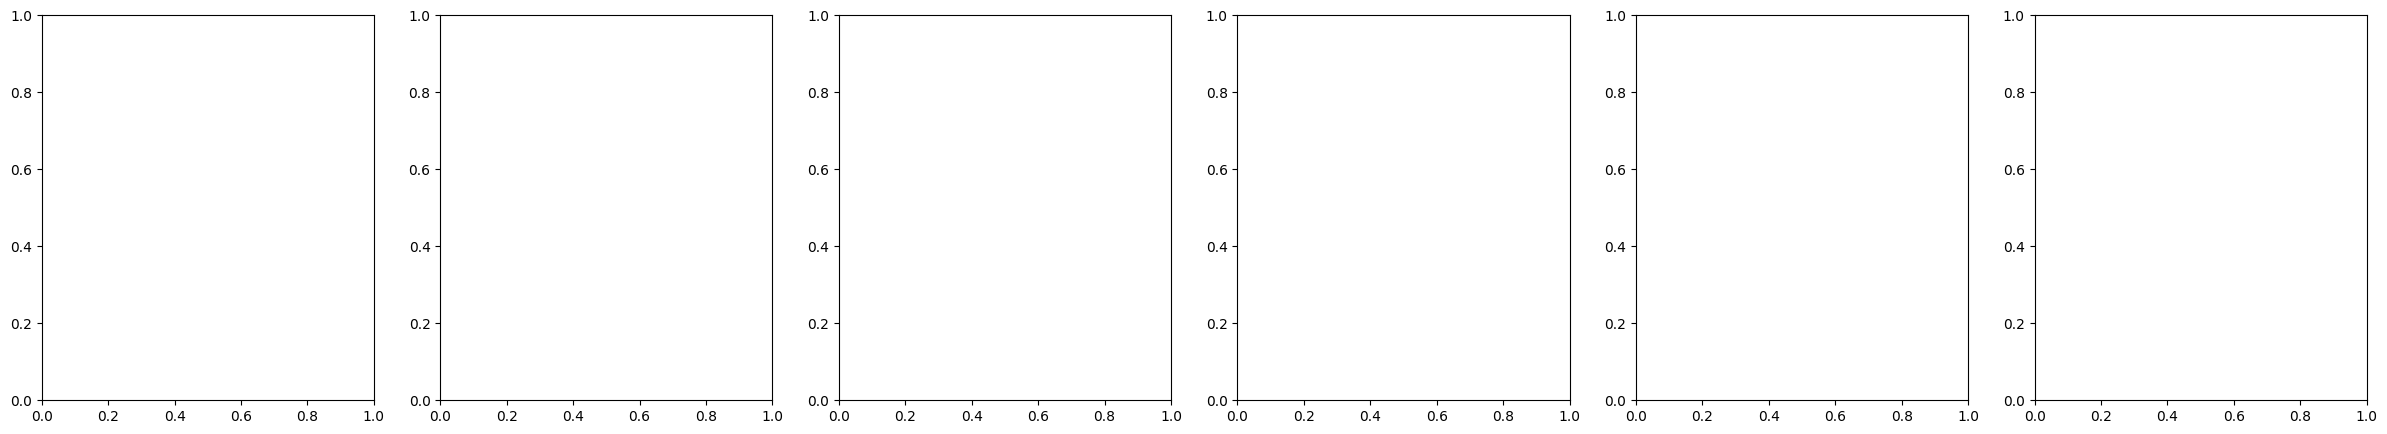

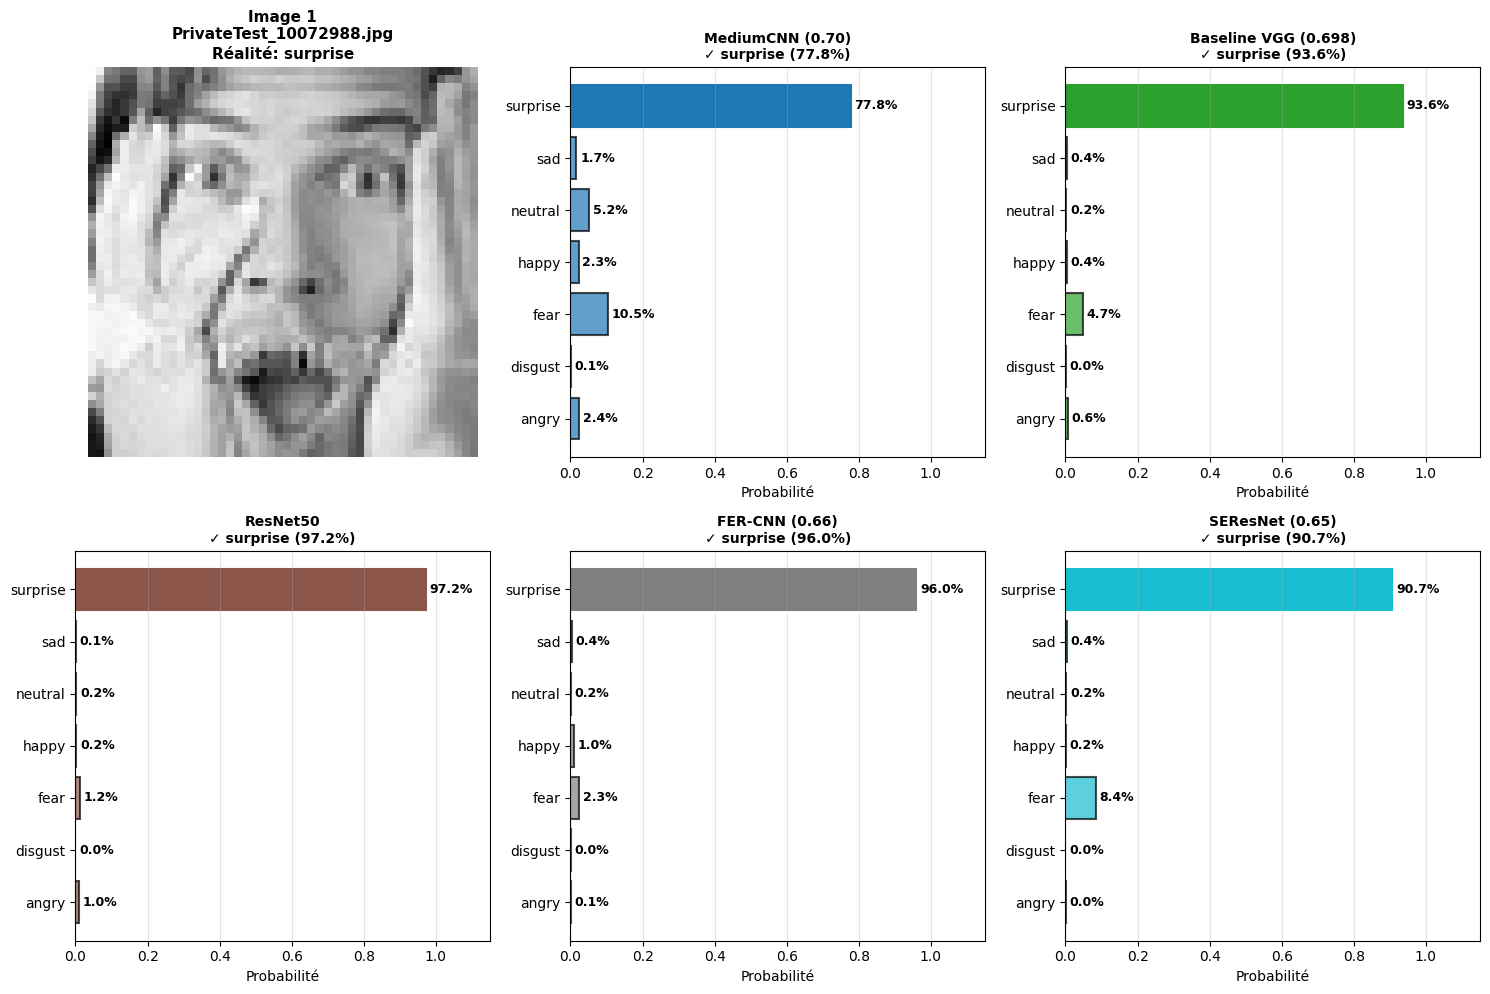

  Image 2: PrivateTest_10089743.jpg
    ✗ MediumCNN (0.70): fear (57.5%)
    ✓ Baseline VGG (0.698): surprise (66.3%)
    ✗ ResNet50: angry (33.4%)
    ✓ FER-CNN (0.66): surprise (72.3%)
    ✓ SEResNet (0.65): surprise (57.1%)


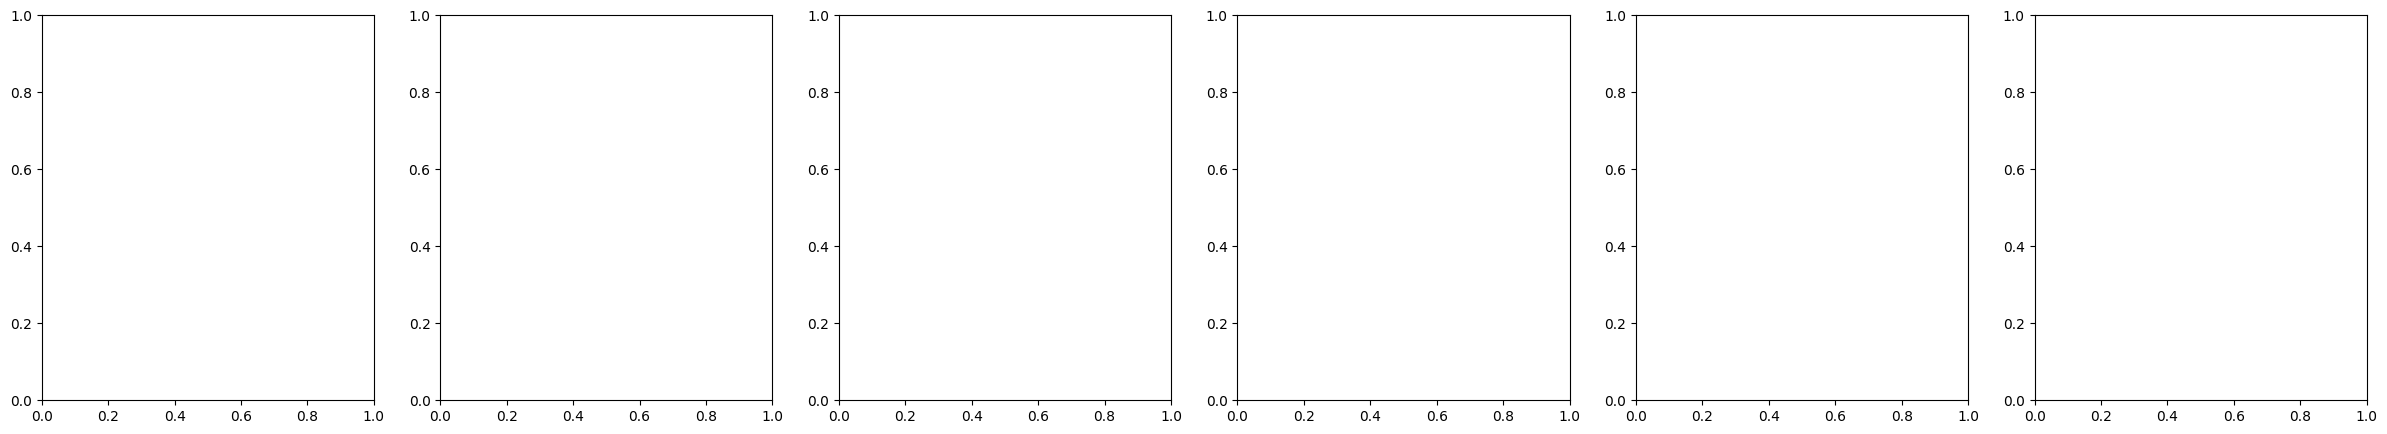

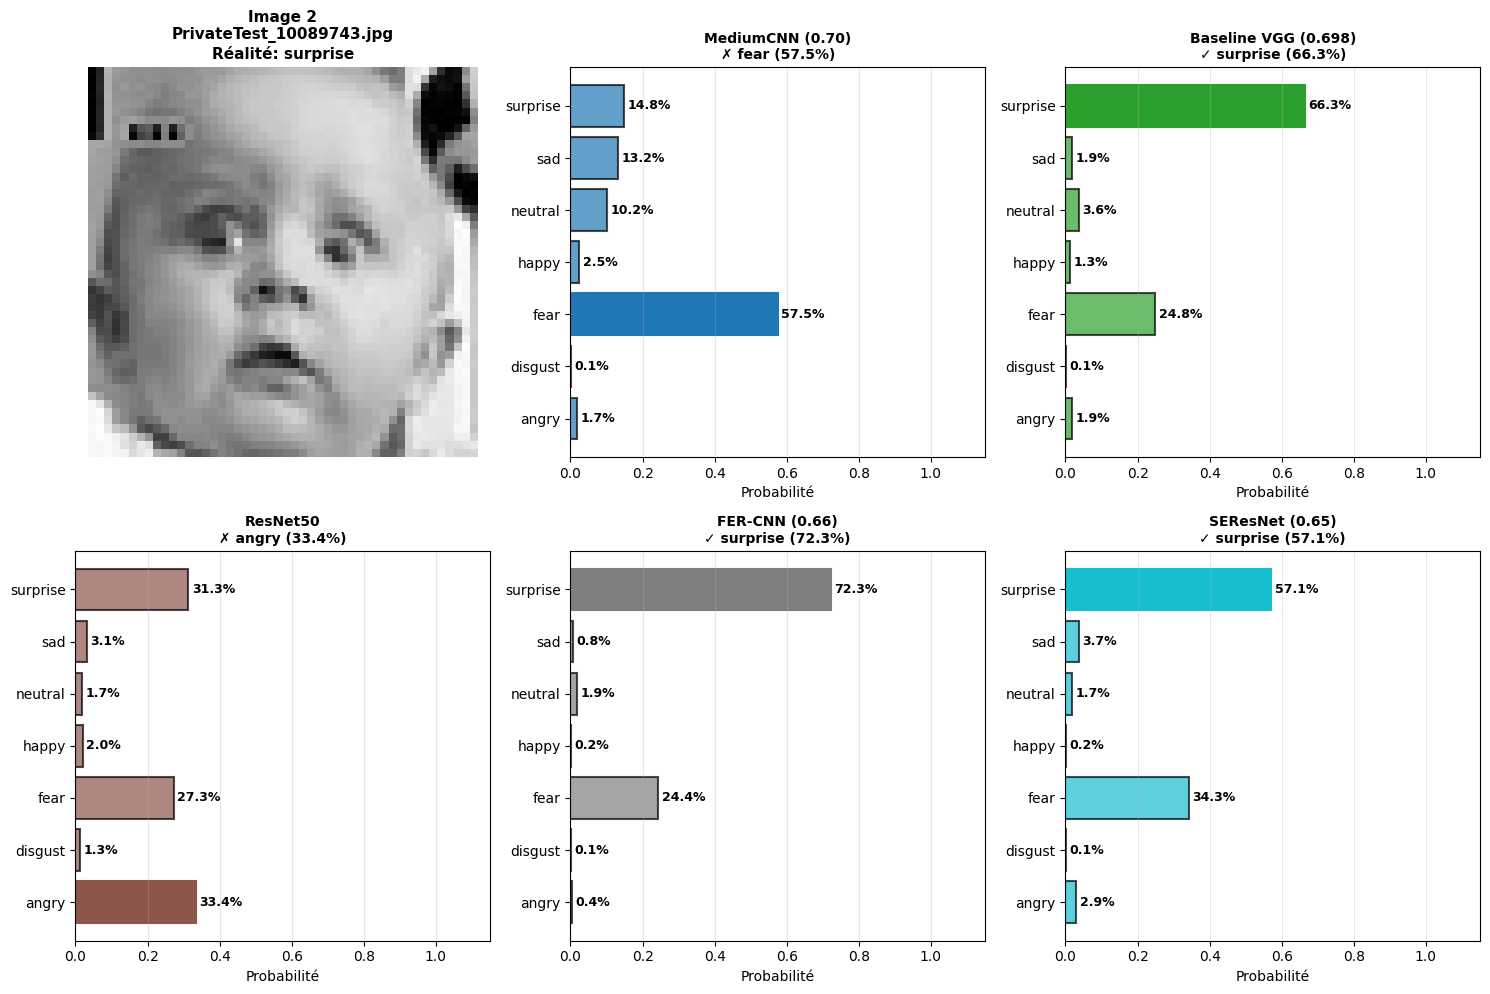

  Image 3: PrivateTest_104142.jpg
    ✗ MediumCNN (0.70): neutral (77.9%)
    ✓ Baseline VGG (0.698): surprise (50.5%)
    ✓ ResNet50: surprise (93.4%)
    ✓ FER-CNN (0.66): surprise (64.6%)
    ✗ SEResNet (0.65): fear (59.5%)


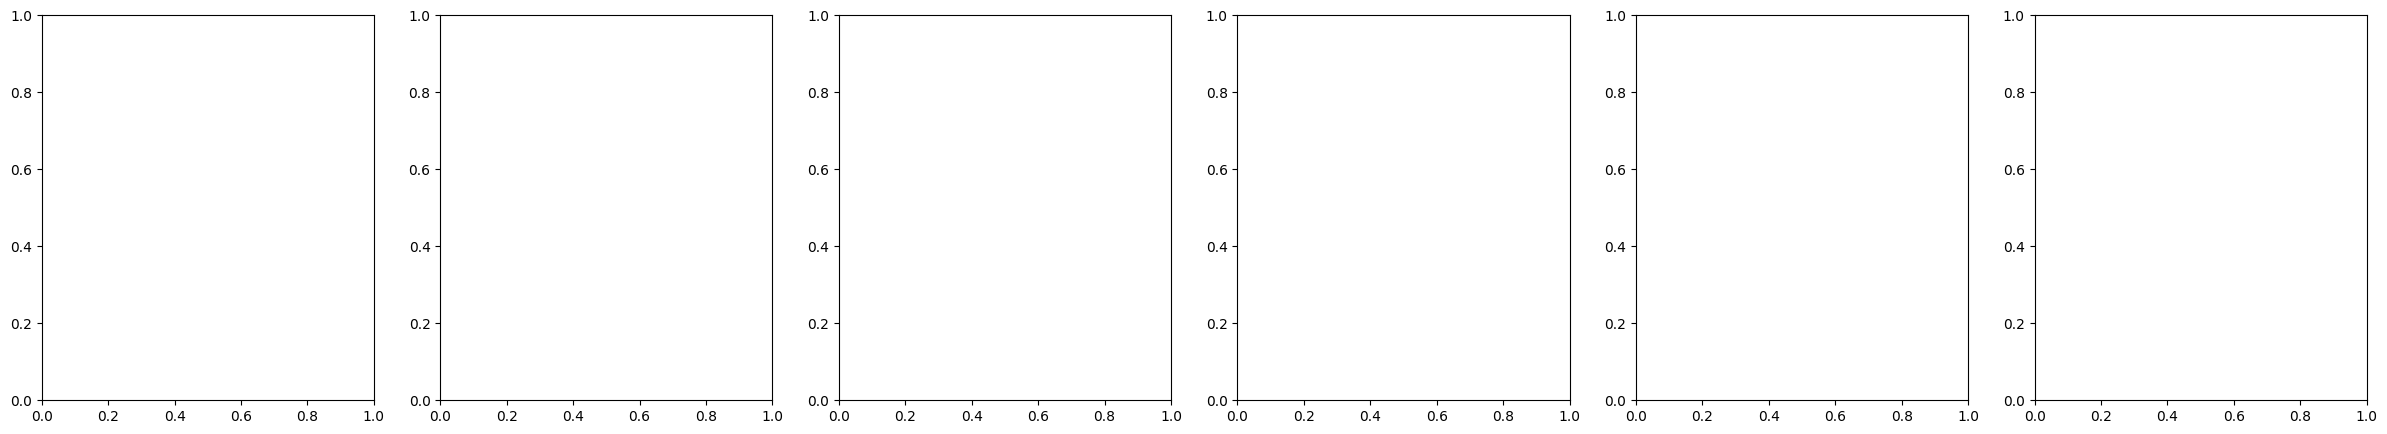

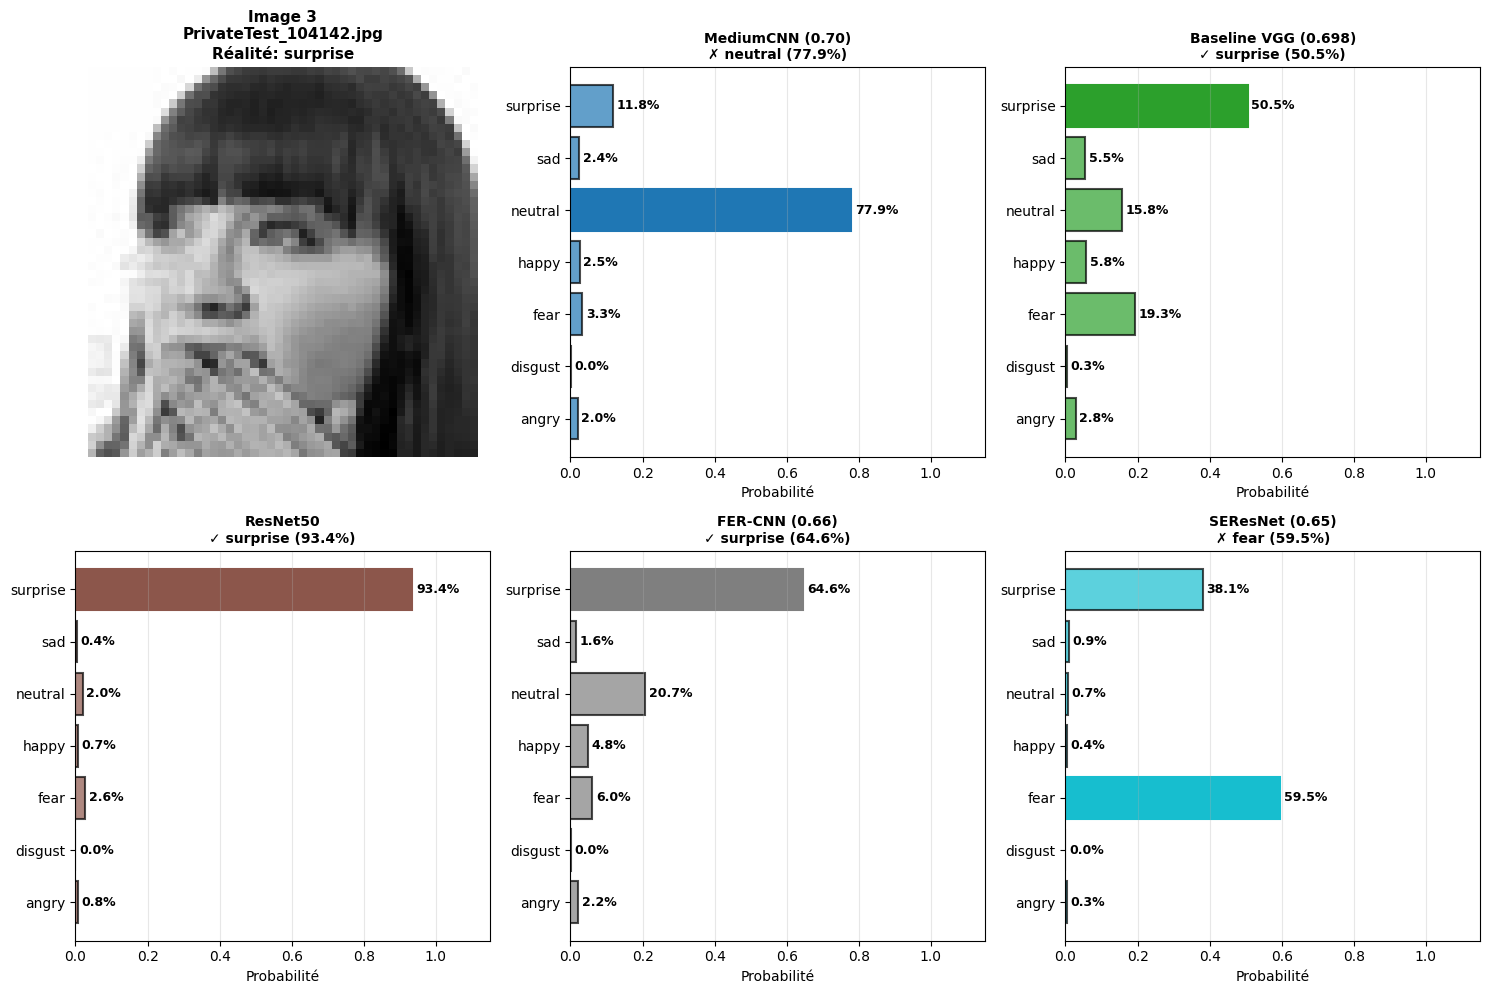


  Résumé (surprise):
    MediumCNN (0.70): 1/3 correct (33%)
    Baseline VGG (0.698): 3/3 correct (100%)
    ResNet50: 2/3 correct (67%)
    FER-CNN (0.66): 3/3 correct (100%)
    SEResNet (0.65): 2/3 correct (67%)



In [ ]:
# ===== ÉVALUER LES MODÈLES SUR PLUSIEURS IMAGES AVEC VISUALISATION =====

import os
from pathlib import Path
from collections import defaultdict

# Créer le répertoire d'évaluation s'il n'existe pas
eval_dir = Path('evaluation')
eval_dir.mkdir(exist_ok=True)

TEST_DATA_PATH = Path('../data/test')

# Obtenir toutes les images de test
test_images_by_emotion = defaultdict(list)
if TEST_DATA_PATH.exists():
    for emotion_dir in sorted(TEST_DATA_PATH.iterdir()):
        if emotion_dir.is_dir():
            images = list(emotion_dir.glob('*.jpg'))
            test_images_by_emotion[emotion_dir.name] = images
    
    if test_images_by_emotion:
        print('='*80)
        print('ÉVALUATION DES MODÈLES SUR LES IMAGES DE TEST')
        print('='*80)
        
        # Résultats par modèle
        results_by_model = {name: [] for name in loaded_models.keys()}
        emotion_names = list(class_mapping.values())
        
        # Déterminer le nombre de modèles pour les visualisations
        num_models = len(loaded_models)
        
        # Générer des couleurs dynamiquement
        import matplotlib.cm as cm
        colors_palette = cm.tab10(np.linspace(0, 1, num_models))
        
        # Tester quelques images par émotion
        for real_emotion, image_paths in sorted(test_images_by_emotion.items()):
            if len(image_paths) == 0:  # Skip empty directories
                continue
                
            print(f'\n📁 Émotion réelle: {real_emotion.upper()} ({len(image_paths)} images)')
            print('-' * 80)
            
            num_samples = min(3, len(image_paths))
            correct_count = {name: 0 for name in loaded_models.keys()}
            
            for img_idx, test_image_path in enumerate(image_paths[:num_samples]):
                try:
                    # Charger et prétraiter
                    test_img_array = preprocess_image(test_image_path)
                    test_img_tensor = torch.from_numpy(test_img_array).float()
                    test_img_tensor = test_img_tensor.unsqueeze(0).unsqueeze(0).to(DEVICE)
                    
                    predictions = {}
                    probabilities_all = {}
                    
                    # Prédictions des modèles
                    for model_name, model in loaded_models.items():
                        with torch.no_grad():
                            outputs = model(test_img_tensor)
                            probabilities = torch.softmax(outputs, dim=1)[0].cpu().numpy()
                            pred_idx = np.argmax(probabilities)
                            pred_emotion = emotion_names[pred_idx]
                            confidence = probabilities[pred_idx]
                            
                            predictions[model_name] = (pred_emotion, confidence)
                            probabilities_all[model_name] = probabilities
                            
                            # Vérifier si correct
                            if pred_emotion.lower() == real_emotion.lower():
                                correct_count[model_name] += 1
                    
                    # Afficher résultats pour cette image
                    print(f'  Image {img_idx + 1}: {test_image_path.name}')
                    for model_name, (pred, conf) in predictions.items():
                        match = '✓' if pred.lower() == real_emotion.lower() else '✗'
                        print(f'    {match} {model_name}: {pred} ({conf:.1%})')
                    
                    # ===== VISUALISER CETTE IMAGE =====
                    fig, axes = plt.subplots(1, num_cols, figsize=(5 * num_cols, 5))
                    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
                    axes = axes.flatten()  # Aplatir pour accès facile
                    
                    # Afficher l'image
                    axes[0].imshow(test_img_array, cmap='gray', interpolation='nearest')
                    axes[0].set_title(f'Image {img_idx + 1}\n{test_image_path.name}\nRéalité: {real_emotion}', 
                                     fontsize=11, fontweight='bold')
                    axes[0].axis('off')
                    
                    # Afficher les prédictions pour chaque modèle
                    model_names = list(predictions.keys())
                    # Afficher les prédictions pour chaque modèle
                    for idx, (model_name, color) in enumerate(zip(model_names, colors_palette)):
                        ax = axes[idx + 1]
                        probs = probabilities_all[model_name]
                        
                        # Créer le graphique en barres
                        bars = ax.barh(emotion_names, probs, color=color, alpha=0.7, edgecolor='black', linewidth=1.5)
                        # Créer le graphique en barres
                        # Mettre en évidence la prédiction la plus probable
                        max_idx = np.argmax(probs)
                        bars[max_idx].set_color(color)
                        bars[max_idx].set_alpha(1.0)
                        
                        # Ajouter les valeurs sur les barres
                        for i, (bar, prob) in enumerate(zip(bars, probs)):
                            width = bar.get_width()
                            ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                                   f'{prob:.1%}', ha='left', va='center', fontsize=9, fontweight='bold')
                        
                        # Configuration
                        ax.set_xlim(0, 1.15)
                        ax.set_xlabel('Probabilité', fontsize=10)
                        pred_emotion, pred_conf = predictions[model_name]
                        match = '✓' if pred_emotion.lower() == real_emotion.lower() else '✗'
                        ax.set_title(f'{model_name}\n{match} {pred_emotion} ({pred_conf:.1%})', fontsize=10, fontweight='bold')
                        ax.grid(axis='x', alpha=0.3)
                    
                    plt.tight_layout()
                    # Sauvegarder avec un nom unique dans le répertoire evaluation
                    save_name = eval_dir / f'test_{real_emotion}_{img_idx + 1}.png'
                    plt.savefig(save_name, dpi=100, bbox_inches='tight')
                    plt.show()
                    
                except Exception as e:
                    print(f'    ✗ Erreur: {e}')
            
            # Résumé par émotion
            print(f'\n  Résumé ({real_emotion}):')
            for model_name in loaded_models.keys():
                if num_samples > 0:
                    accuracy = correct_count[model_name] / num_samples * 100
                    print(f'    {model_name}: {correct_count[model_name]}/{num_samples} correct ({accuracy:.0f}%)')
        
        print('\n' + '='*80)

    else:   
        print(f'❌ Dossier test non trouvé: {TEST_DATA_PATH}')